# Multi-Label Chest X-Ray Disease Classification

# 1. Problem Statement

**Goal:** Frame this as a multi-label classification task where each X-ray can have zero or more disease labels. We aim to achieve state-of-the-art accuracy while handling challenges like label imbalance (e.g., some diseases appear in <1% of images).

**Dataset:** NIH ChestX-ray14 — 112,120 frontal-view X-ray images with 14 disease labels.

**Pipeline Overview:**
1. Data Preparation (preprocessing, augmentation, stratified split)
2. Model Architecture (DenseNet-121 + custom heads)
3. Training with focal loss
   - 4.1.1 Epoch-Level Training Tracker (live diagnostics, early stopping, checkpoints)
4. Evaluation (AUC, F1, confusion matrices)
   - 4.2.4 Inference (single-image, batch, per-class threshold tuning, speed benchmark)
5. Experiments (architecture comparison, augmentation ablation, adversarial training)
6. Interpretability (GradCAM saliency maps)
7. Few-Shot Learning
8. Ethical Considerations

---
## ⚙️ Setup

In [2]:
# === INSTALL DEPENDENCIES ===
# Run once; comment out after first run
# !pip install torch torchvision timm albumentations scikit-learn matplotlib seaborn pandas numpy tqdm opencv-python-headless grad-cam

In [3]:
# === IMPORTS ===
import os
import gc
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    classification_report, average_precision_score
)
from sklearn.preprocessing import MultiLabelBinarizer

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [4]:
# === GLOBAL CONFIG ===
class CFG:
    # Paths
    DATA_DIR     = Path('/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample/')          # dataset root
    IMAGE_DIR    = DATA_DIR / 'images' if DATA_DIR.exists() else '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample/images'
    LABELS_CSV   = DATA_DIR / 'sample_labels.csv' if DATA_DIR.exists() else '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv'
    OUTPUT_DIR   = Path('/kaggle/working')

    # Image
    IMG_SIZE     = 224          # 224 for fast experiments; 512 for full run
    MEAN         = (0.485, 0.456, 0.406)   # ImageNet stats
    STD          = (0.229, 0.224, 0.225)

    # Training
    BATCH_SIZE   = 32
    NUM_WORKERS  = 4
    EPOCHS       = 30
    LR           = 1e-4
    WEIGHT_DECAY = 1e-5
    SEED         = 42

    # Labels
    DISEASE_LABELS = [
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
        'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
        'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
        'Pneumonia', 'Pneumothorax'
    ]
    NUM_CLASSES  = len(DISEASE_LABELS)

    # Focal Loss
    FOCAL_ALPHA  = 0.25
    FOCAL_GAMMA  = 2.0

    # Device
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Config loaded. Device:", CFG.DEVICE)
print(f"Classifying {CFG.NUM_CLASSES} diseases: {CFG.DISEASE_LABELS}")

Config loaded. Device: cuda
Classifying 14 diseases: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [5]:
# === MEMORY MANAGEMENT UTILITIES ===
def free_memory():
    """Force garbage collection + CUDA cache clear."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def memory_stats():
    """Print current GPU memory usage."""
    if torch.cuda.is_available():
        alloc  = torch.cuda.memory_allocated() / 1e9
        reserv = torch.cuda.memory_reserved()  / 1e9
        total  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU Memory | Allocated: {alloc:.2f}GB | Reserved: {reserv:.2f}GB | Total: {total:.2f}GB")
    else:
        print("CPU mode — no GPU memory to report")

memory_stats()

GPU Memory | Allocated: 0.00GB | Reserved: 0.00GB | Total: 15.64GB


---
# 2. Data Preparation

In [6]:
# === LOAD & EXPLORE LABELS CSV ===
# df = pd.read_csv(CFG.LABELS_CSV)
df = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv')
print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (5606, 11)
        Image Index                                     Finding Labels  \
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1  00000013_026.png                             Cardiomegaly|Emphysema   
2  00000017_001.png                                         No Finding   
3  00000030_001.png                                        Atelectasis   
4  00000032_001.png                        Cardiomegaly|Edema|Effusion   

   Follow-up #  Patient ID Patient Age Patient Gender View Position  \
0            5          13        060Y              M            AP   
1           26          13        057Y              M            AP   
2            1          17        077Y              M            AP   
3            1          30        079Y              M            PA   
4            1          32        055Y              F            AP   

   OriginalImageWidth  OriginalImageHeight  OriginalImagePixelSpacing_x  \
0                3056              

In [7]:
# === PARSE MULTI-LABELS ===
# 'Finding Labels' column contains pipe-separated labels e.g. "Atelectasis|Effusion"
df['labels'] = df['Finding Labels'].apply(lambda x: x.split('|'))

# Replace 'No Finding' with empty list
df['labels'] = df['labels'].apply(lambda x: [] if x == ['No Finding'] else x)

# Binary encode using only the 14 official disease classes
mlb = MultiLabelBinarizer(classes=CFG.DISEASE_LABELS)
label_matrix = mlb.fit_transform(df['labels'])
label_df = pd.DataFrame(label_matrix, columns=CFG.DISEASE_LABELS)
df = pd.concat([df.reset_index(drop=True), label_df], axis=1)

print(f"Total samples: {len(df)}")
print(f"No-Finding samples: {(df[CFG.DISEASE_LABELS].sum(axis=1)==0).sum()}")
print("\nPer-label counts:")
print(df[CFG.DISEASE_LABELS].sum().sort_values(ascending=False))

Total samples: 5606
No-Finding samples: 3044

Per-label counts:
Infiltration          967
Effusion              644
Atelectasis           508
Nodule                313
Mass                  284
Pneumothorax          271
Consolidation         226
Pleural_Thickening    176
Cardiomegaly          141
Emphysema             127
Edema                 118
Fibrosis               84
Pneumonia              62
Hernia                 13
dtype: int64


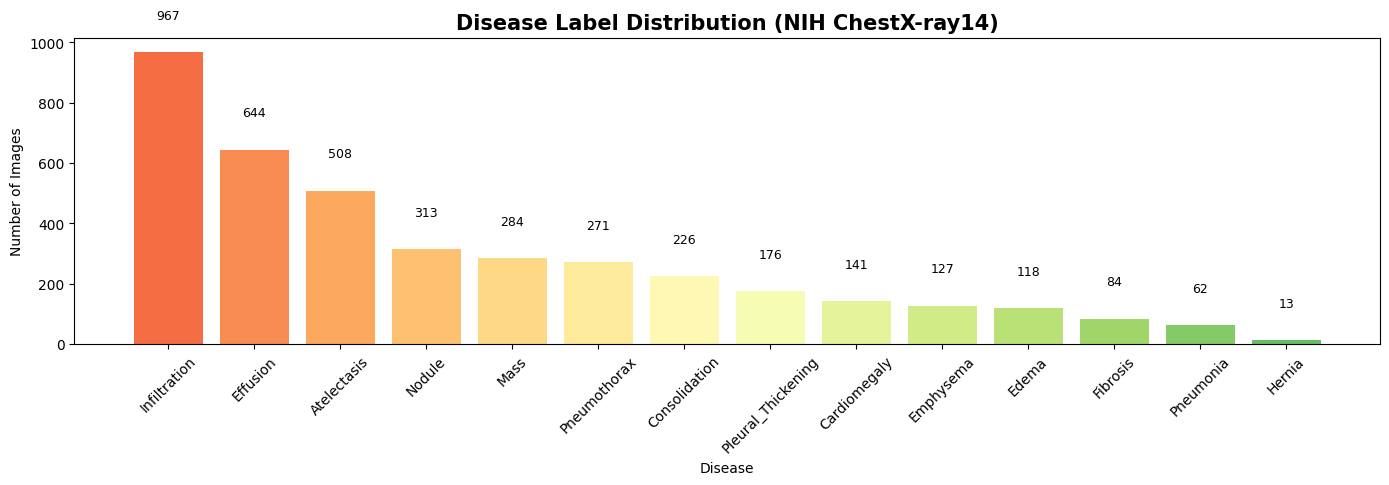

Label imbalance ratio (most/least frequent): 74.4


In [8]:
# === VISUALIZE LABEL DISTRIBUTION ===
label_counts = df[CFG.DISEASE_LABELS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(label_counts))))
ax.set_title('Disease Label Distribution (NIH ChestX-ray14)', fontsize=15, fontweight='bold')
ax.set_xlabel('Disease')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'label_distribution.png', dpi=150)
plt.show()
print("Label imbalance ratio (most/least frequent):",
      round(label_counts.max() / label_counts.min(), 1))

## 2.1. Preprocess Images

### 2.1.1 Resize Images

In [9]:
# Resize is handled inside the Dataset/transform pipeline.
# Here we define the base resize transform used at inference.
resize_transform = T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
print(f"Target image size: {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")

Target image size: 224x224


### 2.1.2. Normalize

In [10]:
# Using ImageNet mean/std — standard practice for transfer learning from ImageNet-pretrained models.
normalize = T.Normalize(mean=CFG.MEAN, std=CFG.STD)
print(f"Normalization — Mean: {CFG.MEAN}  Std: {CFG.STD}")

Normalization — Mean: (0.485, 0.456, 0.406)  Std: (0.229, 0.224, 0.225)


### 2.1.3. Apply Augmentations

In [11]:
# === AUGMENTATION PIPELINES (Albumentations) ===

train_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.3),
    A.GaussNoise(var_limit=(5, 25), p=0.2),
    A.CLAHE(clip_limit=2.0, p=0.2),        # enhance local contrast for X-rays
    A.Normalize(mean=CFG.MEAN, std=CFG.STD),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=CFG.MEAN, std=CFG.STD),
    ToTensorV2(),
])

print("Train transforms:", [t.__class__.__name__ for t in train_transforms.transforms])
print("Val transforms  :", [t.__class__.__name__ for t in val_transforms.transforms])

Train transforms: ['Resize', 'HorizontalFlip', 'Rotate', 'RandomBrightnessContrast', 'ShiftScaleRotate', 'GaussNoise', 'CLAHE', 'Normalize', 'ToTensorV2']
Val transforms  : ['Resize', 'Normalize', 'ToTensorV2']


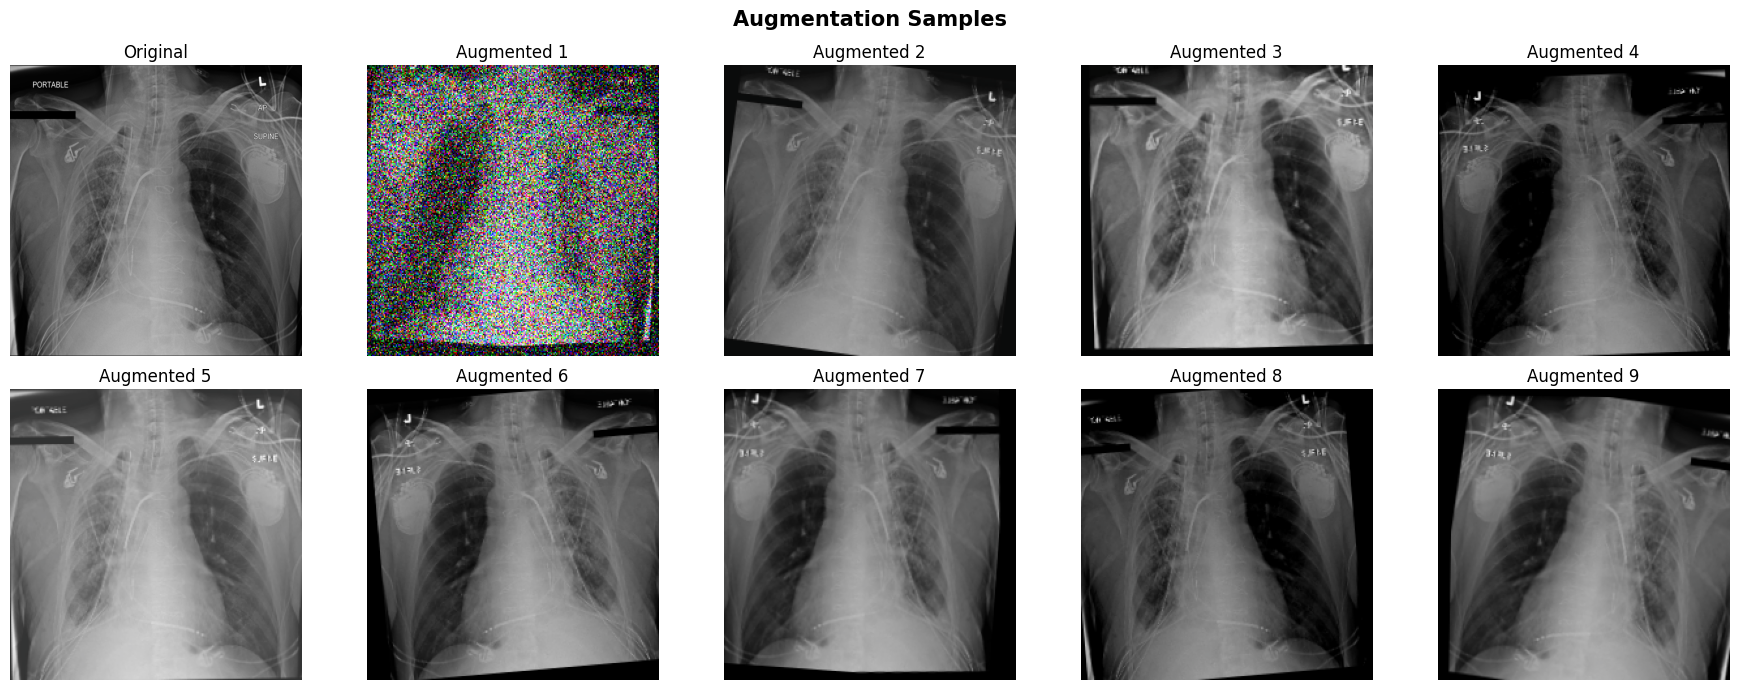

In [12]:
# === VISUALIZE AUGMENTATIONS ON A SAMPLE IMAGE ===
sample_img_path = CFG.IMAGE_DIR / df['Image Index'].iloc[0]
if sample_img_path.exists():
    orig_img = np.array(Image.open(sample_img_path).convert('RGB'))
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle('Augmentation Samples', fontsize=15, fontweight='bold')
    axes[0, 0].imshow(orig_img, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    for i, ax in enumerate(axes.flat[1:], 1):
        aug = train_transforms(image=orig_img)['image']
        # Denormalize for display
        aug_disp = aug.permute(1,2,0).numpy()
        aug_disp = aug_disp * np.array(CFG.STD) + np.array(CFG.MEAN)
        aug_disp = np.clip(aug_disp, 0, 1)
        ax.imshow(aug_disp)
        ax.set_title(f'Augmented {i}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(CFG.OUTPUT_DIR / 'augmentation_samples.png', dpi=150)
    plt.show()
else:
    print("Sample image not found — adjust IMAGE_DIR path.")

## 2.2. Stratified Train / Val / Test Split

In [13]:
# === STRATIFIED SPLIT ===
# Multi-label stratification: use the most frequent label per image as the stratify key.
# For a more rigorous split use iterative-stratification (pip install iterative-stratification).

df['primary_label'] = df['labels'].apply(
    lambda x: x[0] if len(x) > 0 else 'No Finding'
)

stratify_df = df['primary_label']  if df['primary_label'].value_counts().min() > 1 else None
train_df, temp_df = train_test_split(
    df, 
    test_size=0.20, 
    stratify=stratify_df , 
    random_state=CFG.SEED
)

stratify_temp_df = temp_df['primary_label']  if temp_df['primary_label'].value_counts().min() > 1 else None
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    stratify=stratify_temp_df , 
    random_state=CFG.SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):>6,}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val  : {len(val_df):>6,}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test : {len(test_df):>6,}  ({len(test_df)/len(df)*100:.1f}%)")

Train:  4,484  (80.0%)
Val  :    561  (10.0%)
Test :    561  (10.0%)


In [14]:
# === DATASET CLASS ===
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.labels    = self.df[CFG.DISEASE_LABELS].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.image_dir / self.df.loc[idx, 'Image Index']
        image    = np.array(Image.open(img_path).convert('RGB'))
        label    = self.labels[idx]
        if self.transform:
            image = self.transform(image=image)['image']
        return image, torch.tensor(label, dtype=torch.float32)

# Build datasets
train_dataset = ChestXrayDataset(train_df, CFG.IMAGE_DIR, train_transforms)
val_dataset   = ChestXrayDataset(val_df,   CFG.IMAGE_DIR, val_transforms)
test_dataset  = ChestXrayDataset(test_df,  CFG.IMAGE_DIR, val_transforms)

# Build data loaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 141 | Val batches: 18 | Test batches: 18


---
# 3. Model Architecture

## 3.1. Pre-trained Backbone — DenseNet-121

In [15]:
# === DENSENET-121 BACKBONE ===
def build_densenet121(num_classes=CFG.NUM_CLASSES, pretrained=True):
    """
    DenseNet-121 pretrained on ImageNet.
    Replace the classifier head with a sigmoid-activated multi-label head.
    """
    model = timm.create_model('densenet121', pretrained=pretrained)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
        # NOTE: No sigmoid here — we apply it outside for numerical stability with BCEWithLogitsLoss
    )
    return model

model = build_densenet121()
model = model.to(CFG.DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
memory_stats()

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Total parameters    : 7,485,838
Trainable parameters: 7,485,838
GPU Memory | Allocated: 0.03GB | Reserved: 0.05GB | Total: 15.64GB


## 3.2. Classification Head — Sigmoid Activation

In [16]:
# The classification head is defined inside build_densenet121().
# At inference time, we apply sigmoid to get per-class probabilities.
#
# Architecture summary:
#   DenseNet-121 backbone  →  Global Average Pool  →
#   Linear(1024, 512)  →  ReLU  →  Dropout(0.3)  →
#   Linear(512, 14)    →  [Sigmoid at inference]

# Quick forward-pass sanity check
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(CFG.DEVICE)
    logits = model(dummy)
    probs  = torch.sigmoid(logits)
print(f"Logits shape : {logits.shape}")
print(f"Probs  shape : {probs.shape}")
print(f"Sample probs : {probs[0].cpu().numpy().round(3)}")

Logits shape : torch.Size([2, 14])
Probs  shape : torch.Size([2, 14])
Sample probs : [0.465 0.494 0.49  0.494 0.531 0.477 0.515 0.499 0.483 0.503 0.474 0.484
 0.501 0.48 ]


## 3.3. Advanced: Custom Loss Function & Vision Transformer

### 3.3.1. Focal Loss (addresses class imbalance)

In [17]:
# === FOCAL LOSS ===
class FocalLoss(nn.Module):
    """
    Binary Focal Loss for multi-label classification.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Addresses class imbalance by down-weighting easy negatives.
    """
    def __init__(self, alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA, reduction='mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        probs  = torch.sigmoid(logits)
        p_t    = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        focal_loss   = focal_weight * bce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Compare focal loss vs BCEWithLogitsLoss on synthetic data
criterion_focal = FocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
criterion_bce   = nn.BCEWithLogitsLoss()

test_logits  = torch.randn(4, CFG.NUM_CLASSES)
test_targets = torch.randint(0, 2, (4, CFG.NUM_CLASSES)).float()
print(f"Focal Loss : {criterion_focal(test_logits, test_targets).item():.4f}")
print(f"BCE Loss   : {criterion_bce(test_logits, test_targets).item():.4f}")

Focal Loss : 0.1695
BCE Loss   : 0.7957


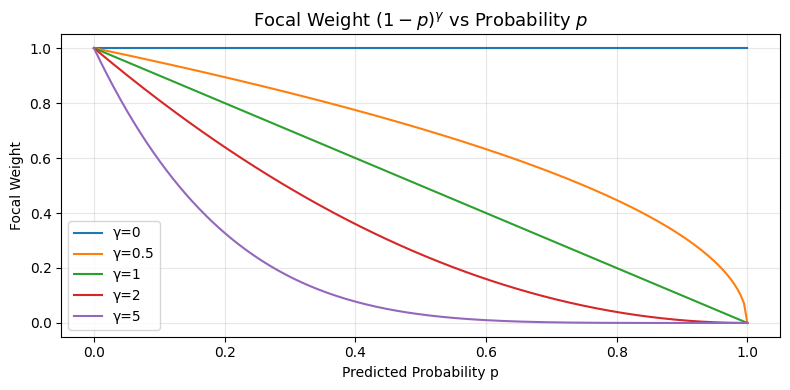

Higher gamma = more down-weighting of easy examples


In [18]:
# === VISUALIZE FOCAL WEIGHT vs PROBABILITY ===
fig, ax = plt.subplots(figsize=(8, 4))
p = np.linspace(0, 1, 200)
for gamma in [0, 0.5, 1, 2, 5]:
    weight = (1 - p) ** gamma
    ax.plot(p, weight, label=f'γ={gamma}')
ax.set_title('Focal Weight $(1-p)^\\gamma$ vs Probability $p$', fontsize=13)
ax.set_xlabel('Predicted Probability p')
ax.set_ylabel('Focal Weight')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'focal_weight.png', dpi=150)
plt.show()
print("Higher gamma = more down-weighting of easy examples")

### 3.3.2. Vision Transformer (ViT) — for comparison

In [19]:
# === VISION TRANSFORMER (ViT-B/16) ===
def build_vit(num_classes=CFG.NUM_CLASSES, pretrained=True):
    """
    ViT-Base/16 pretrained on ImageNet-21k.
    Uses timm for a clean interface.
    """
    model = timm.create_model('vit_base_patch16_224', pretrained=pretrained)
    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

vit_model = build_vit()
vit_model = vit_model.to(CFG.DEVICE)

vit_total = sum(p.numel() for p in vit_model.parameters())
print(f"ViT-B/16 parameters: {vit_total:,}")

# Sanity check
vit_model.eval()
with torch.no_grad():
    out = vit_model(dummy)
print(f"ViT output shape: {out.shape}")
free_memory()

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 parameters: 86,199,566
ViT output shape: torch.Size([2, 14])


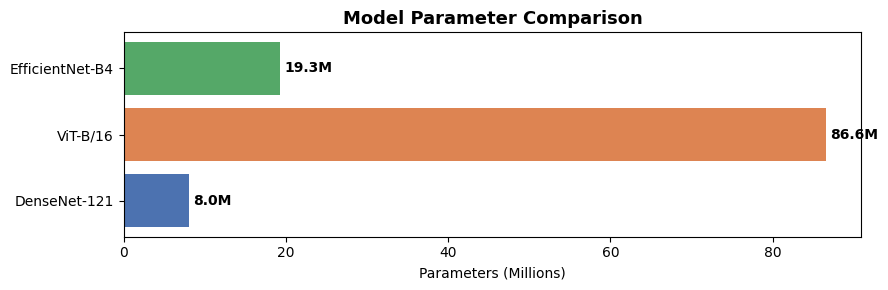

In [20]:
# === ARCHITECTURE SUMMARY ===
fig, ax = plt.subplots(figsize=(9, 3))
architectures = {
    'DenseNet-121': {'params_M': 8.0,  'imagenet_top1': 74.9, 'color': '#4C72B0'},
    'ViT-B/16'    : {'params_M': 86.6, 'imagenet_top1': 81.8, 'color': '#DD8452'},
    'EfficientNet-B4': {'params_M': 19.3, 'imagenet_top1': 83.0, 'color': '#55A868'},
}
names  = list(architectures.keys())
params = [v['params_M'] for v in architectures.values()]
colors = [v['color']    for v in architectures.values()]
bars = ax.barh(names, params, color=colors)
for bar, val in zip(bars, params):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}M', va='center', fontweight='bold')
ax.set_title('Model Parameter Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameters (Millions)')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'model_params.png', dpi=150)
plt.show()

---
# 4. Training, Evaluation and Inference

## 4.1. Training Loop

In [21]:
# === TRAINING UTILITIES ===

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    all_targets, all_probs = [], []

    for images, targets in tqdm(loader, desc='Train', leave=False):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        if scaler is not None:  # AMP (mixed-precision)
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss   = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss   = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    auc = roc_auc_score(all_targets, all_probs, average='macro')
    return avg_loss, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets, all_probs = [], []

    for images, targets in tqdm(loader, desc='Eval ', leave=False):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        logits  = model(images)
        loss    = criterion(logits, targets)
        total_loss += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    avg_loss    = total_loss / len(loader.dataset)
    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    auc         = roc_auc_score(all_targets, all_probs, average='macro')
    return avg_loss, auc, all_targets, all_probs


def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss'])+1)

    axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
    axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='s', markersize=3)
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_auc'], label='Train', marker='o', markersize=3)
    axes[1].plot(epochs, history['val_auc'],   label='Val',   marker='s', markersize=3)
    axes[1].set_title('Macro AUC per Epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Training History — DenseNet-121', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG.OUTPUT_DIR / 'training_history.png', dpi=150)
    plt.show()

print("Training utilities defined.")

Training utilities defined.


Epoch [01/30]  Train Loss: 0.0242  Train AUC: 0.5546  Val Loss: 0.0177  Val AUC: 0.6634  ✓ Saved


Epoch [02/30]  Train Loss: 0.0173  Train AUC: 0.6361  Val Loss: 0.0173  Val AUC: 0.6863  ✓ Saved


Epoch [03/30]  Train Loss: 0.0169  Train AUC: 0.6652  Val Loss: 0.0169  Val AUC: 0.7102  ✓ Saved


Epoch [04/30]  Train Loss: 0.0164  Train AUC: 0.6966  Val Loss: 0.0171  Val AUC: 0.7203  ✓ Saved


Epoch [05/30]  Train Loss: 0.0158  Train AUC: 0.7256  Val Loss: 0.0169  Val AUC: 0.7313  ✓ Saved


...

Epoch [26/30]  Train Loss: 0.0077  Train AUC: 0.9579  Val Loss: 0.0241  Val AUC: 0.6922  


Epoch [27/30]  Train Loss: 0.0077  Train AUC: 0.9560  Val Loss: 0.0238  Val AUC: 0.6894  


Epoch [28/30]  Train Loss: 0.0075  Train AUC: 0.9624  Val Loss: 0.0243  Val AUC: 0.6889  


Epoch [29/30]  Train Loss: 0.0074  Train AUC: 0.9618  Val Loss: 0.0242  Val AUC: 0.6900  


Epoch [30/30]  Train Loss: 0.0077  Train AUC: 0.9581  Val Loss: 0.0242  Val AUC: 0.6844  

Best Val AUC: 0.7533


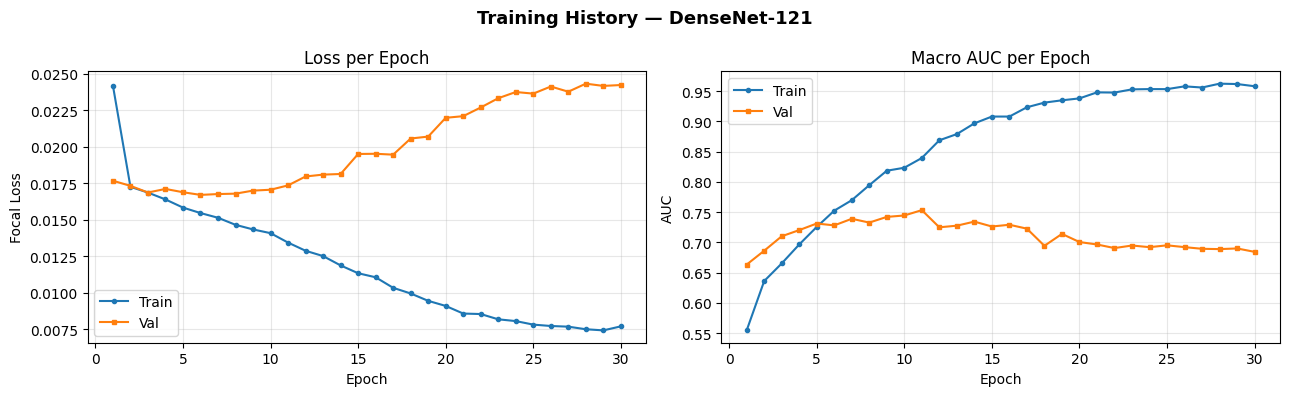

In [22]:
# === MAIN TRAINING LOOP ===
model      = build_densenet121().to(CFG.DEVICE)
criterion  = FocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
optimizer  = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
scaler     = torch.cuda.amp.GradScaler() if CFG.DEVICE == 'cuda' else None

best_auc   = 0.0
history    = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

for epoch in range(1, CFG.EPOCHS + 1):
    train_loss, train_auc = train_one_epoch(model, train_loader, optimizer, criterion, CFG.DEVICE, scaler)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, CFG.DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    print(f"Epoch [{epoch:02d}/{CFG.EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train AUC: {train_auc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val AUC: {val_auc:.4f}",
          end='  ')

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), CFG.OUTPUT_DIR / 'densenet121_best.pth')
        print("✓ Saved")
    else:
        print()

    free_memory()

print(f"\nBest Val AUC: {best_auc:.4f}")
plot_training_history(history)

## 4.1.1. Epoch-Level Training Tracker

Detailed per-epoch diagnostics: live loss/AUC table, learning-rate curve, gradient-norm tracking, early stopping, and epoch checkpoint management.

In [23]:
# === EPOCH TRACKER — RICH PER-EPOCH DIAGNOSTICS ===
import time
from collections import defaultdict

class EpochTracker:
    """
    Tracks and displays per-epoch statistics:
      - Train / Val loss and AUC
      - Learning rate per epoch
      - Gradient norm per epoch
      - Time per epoch
      - Early stopping logic
      - Saves per-epoch checkpoints (optional)
    """
    def __init__(self, patience=7, save_every_n=5,
                 checkpoint_dir=CFG.OUTPUT_DIR / 'epoch_ckpts'):
        self.patience       = patience
        self.save_every_n   = save_every_n
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

        self.records        = defaultdict(list)   # epoch → metrics
        self.best_auc       = 0.0
        self.best_epoch     = 0
        self.patience_ctr   = 0
        self.epoch_times    = []
        self._t0            = None

    # ── Timing ────────────────────────────────────────────────
    def start_epoch(self):
        self._t0 = time.time()

    def end_epoch(self):
        elapsed = time.time() - self._t0
        self.epoch_times.append(elapsed)
        return elapsed

    # ── Gradient norm ─────────────────────────────────────────
    @staticmethod
    def grad_norm(model):
        total = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total += p.grad.detach().norm(2).item() ** 2
        return total ** 0.5

    # ── Record & display ──────────────────────────────────────
    def record(self, epoch, train_loss, train_auc,
               val_loss, val_auc, lr, gnorm):
        self.records['epoch'].append(epoch)
        self.records['train_loss'].append(train_loss)
        self.records['train_auc'].append(train_auc)
        self.records['val_loss'].append(val_loss)
        self.records['val_auc'].append(val_auc)
        self.records['lr'].append(lr)
        self.records['grad_norm'].append(gnorm)
        self.records['time_s'].append(self.epoch_times[-1] if self.epoch_times else 0.0)

    def print_row(self, epoch, total_epochs, train_loss, train_auc,
                  val_loss, val_auc, lr, gnorm, elapsed, saved):
        tag = '✓' if saved else ' '
        print(
            f"[{tag}] Ep {epoch:03d}/{total_epochs} | "
            f"T-Loss: {train_loss:.4f}  T-AUC: {train_auc:.4f} | "
            f"V-Loss: {val_loss:.4f}  V-AUC: {val_auc:.4f} | "
            f"LR: {lr:.2e}  GN: {gnorm:.2f}  {elapsed:.0f}s"
        )

    # ── Checkpoint saving ─────────────────────────────────────
    def maybe_save(self, epoch, model, val_auc):
        saved = False
        # Best model
        if val_auc > self.best_auc:
            self.best_auc   = val_auc
            self.best_epoch = epoch
            self.patience_ctr = 0
            torch.save(model.state_dict(),
                       CFG.OUTPUT_DIR / 'densenet121_best.pth')
            saved = True
        else:
            self.patience_ctr += 1
        # Periodic checkpoint every N epochs
        if epoch % self.save_every_n == 0:
            torch.save(model.state_dict(),
                       self.checkpoint_dir / f'ckpt_epoch_{epoch:03d}.pth')
        return saved

    # ── Early stopping check ──────────────────────────────────
    def should_stop(self):
        return self.patience_ctr >= self.patience

    # ── Summary table ─────────────────────────────────────────
    def summary_table(self):
        df_rec = pd.DataFrame(self.records)
        print("\n" + "=" * 85)
        print(" EPOCH-BY-EPOCH TRAINING SUMMARY")
        print("=" * 85)
        print(df_rec.to_string(index=False,
              float_format=lambda x: f'{x:.4f}'))
        print("=" * 85)
        print(f"Best Val AUC: {self.best_auc:.4f}  @ Epoch {self.best_epoch}")
        print(f"Total training time: {sum(self.epoch_times)/60:.1f} min")
        return df_rec

print("EpochTracker class defined.")

EpochTracker class defined.


In [24]:
# === FULL TRAINING LOOP WITH EPOCH TRACKER ===
# Re-initialise model, optimiser, and scheduler for a clean run.

model      = build_densenet121().to(CFG.DEVICE)
criterion  = FocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
optimizer  = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
scaler     = torch.cuda.amp.GradScaler() if CFG.DEVICE == 'cuda' else None

tracker    = EpochTracker(patience=7, save_every_n=5)
best_auc   = 0.0
history    = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

print(f"Starting training — {CFG.EPOCHS} epochs | Device: {CFG.DEVICE}")
print("-" * 85)

for epoch in range(1, CFG.EPOCHS + 1):
    tracker.start_epoch()

    # ── Train ────────────────────────────────────────────────
    model.train()
    epoch_loss, epoch_probs, epoch_targets = 0.0, [], []
    epoch_gnorms = []

    for images, targets in tqdm(train_loader, desc=f'Ep {epoch:03d} Train', leave=False):
        images  = images.to(CFG.DEVICE, non_blocking=True)
        targets = targets.to(CFG.DEVICE, non_blocking=True)
        optimizer.zero_grad()

        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss   = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            epoch_gnorms.append(tracker.grad_norm(model))
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss   = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            epoch_gnorms.append(tracker.grad_norm(model))
            optimizer.step()

        epoch_loss    += loss.item() * images.size(0)
        epoch_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        epoch_targets.append(targets.detach().cpu().numpy())

    train_loss  = epoch_loss / len(train_loader.dataset)
    train_probs = np.vstack(epoch_probs)
    train_gt    = np.vstack(epoch_targets)
    train_auc   = roc_auc_score(train_gt, train_probs, average='macro')
    mean_gnorm  = float(np.mean(epoch_gnorms))

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ── Validate ─────────────────────────────────────────────
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, CFG.DEVICE)
    elapsed = tracker.end_epoch()

    # ── Record, checkpoint, display ──────────────────────────
    saved = tracker.maybe_save(epoch, model, val_auc)
    tracker.record(epoch, train_loss, train_auc, val_loss, val_auc,
                   current_lr, mean_gnorm)
    tracker.print_row(epoch, CFG.EPOCHS, train_loss, train_auc,
                      val_loss, val_auc, current_lr, mean_gnorm,
                      elapsed, saved)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    # ── Memory cleanup ────────────────────────────────────────
    free_memory()

    # ── Early stopping ────────────────────────────────────────
    if tracker.should_stop():
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement for {tracker.patience} epochs).")
        break

best_auc = tracker.best_auc
print(f"\nTraining complete. Best Val AUC: {best_auc:.4f} @ Epoch {tracker.best_epoch}")

Starting training — 30 epochs | Device: cuda
-------------------------------------------------------------------------------------


[✓] Ep 001/30 | T-Loss: 0.0240  T-AUC: 0.5521 | V-Loss: 0.0178  V-AUC: 0.6413 | LR: 9.97e-05  GN: 0.12  46s


[✓] Ep 002/30 | T-Loss: 0.0172  T-AUC: 0.6296 | V-Loss: 0.0172  V-AUC: 0.6753 | LR: 9.89e-05  GN: 0.08  46s


[✓] Ep 003/30 | T-Loss: 0.0167  T-AUC: 0.6560 | V-Loss: 0.0171  V-AUC: 0.6920 | LR: 9.76e-05  GN: 0.07  46s


[✓] Ep 004/30 | T-Loss: 0.0162  T-AUC: 0.6896 | V-Loss: 0.0170  V-AUC: 0.7056 | LR: 9.57e-05  GN: 0.07  46s


...

[ ] Ep 009/30 | T-Loss: 0.0142  T-AUC: 0.8148 | V-Loss: 0.0172  V-AUC: 0.7090 | LR: 7.96e-05  GN: 0.07  46s


[ ] Ep 010/30 | T-Loss: 0.0138  T-AUC: 0.8380 | V-Loss: 0.0174  V-AUC: 0.7123 | LR: 7.52e-05  GN: 0.07  46s


[ ] Ep 011/30 | T-Loss: 0.0133  T-AUC: 0.8450 | V-Loss: 0.0179  V-AUC: 0.7135 | LR: 7.06e-05  GN: 0.08  46s


[ ] Ep 012/30 | T-Loss: 0.0127  T-AUC: 0.8666 | V-Loss: 0.0179  V-AUC: 0.7064 | LR: 6.58e-05  GN: 0.08  46s


[ ] Ep 013/30 | T-Loss: 0.0122  T-AUC: 0.8730 | V-Loss: 0.0188  V-AUC: 0.7060 | LR: 6.08e-05  GN: 0.08  46s

Early stopping triggered at epoch 13 (no improvement for 7 epochs).

Training complete. Best Val AUC: 0.7257 @ Epoch 6


In [25]:
# === EPOCH SUMMARY TABLE ===
epoch_df = tracker.summary_table()


 EPOCH-BY-EPOCH TRAINING SUMMARY
 epoch  train_loss  train_auc  val_loss  val_auc     lr  grad_norm  time_s
     1      0.0240     0.5521    0.0178   0.6413 0.0001     0.1212 45.8794
     2      0.0172     0.6296    0.0172   0.6753 0.0001     0.0795 46.2736
     3      0.0167     0.6560    0.0171   0.6920 0.0001     0.0739 46.2949
     4      0.0162     0.6896    0.0170   0.7056 0.0001     0.0701 45.9048
     5      0.0158     0.7168    0.0170   0.7112 0.0001     0.0695 45.8074
     6      0.0155     0.7371    0.0167   0.7257 0.0001     0.0701 46.1280
     7      0.0150     0.7697    0.0172   0.7158 0.0001     0.0676 46.0960
     8      0.0146     0.7968    0.0170   0.7205 0.0001     0.0687 45.9500
     9      0.0142     0.8148    0.0172   0.7090 0.0001     0.0701 45.9957
    10      0.0138     0.8380    0.0174   0.7123 0.0001     0.0724 46.1289
    11      0.0133     0.8450    0.0179   0.7135 0.0001     0.0754 46.4298
    12      0.0127     0.8666    0.0179   0.7064 0.0001     0.0779

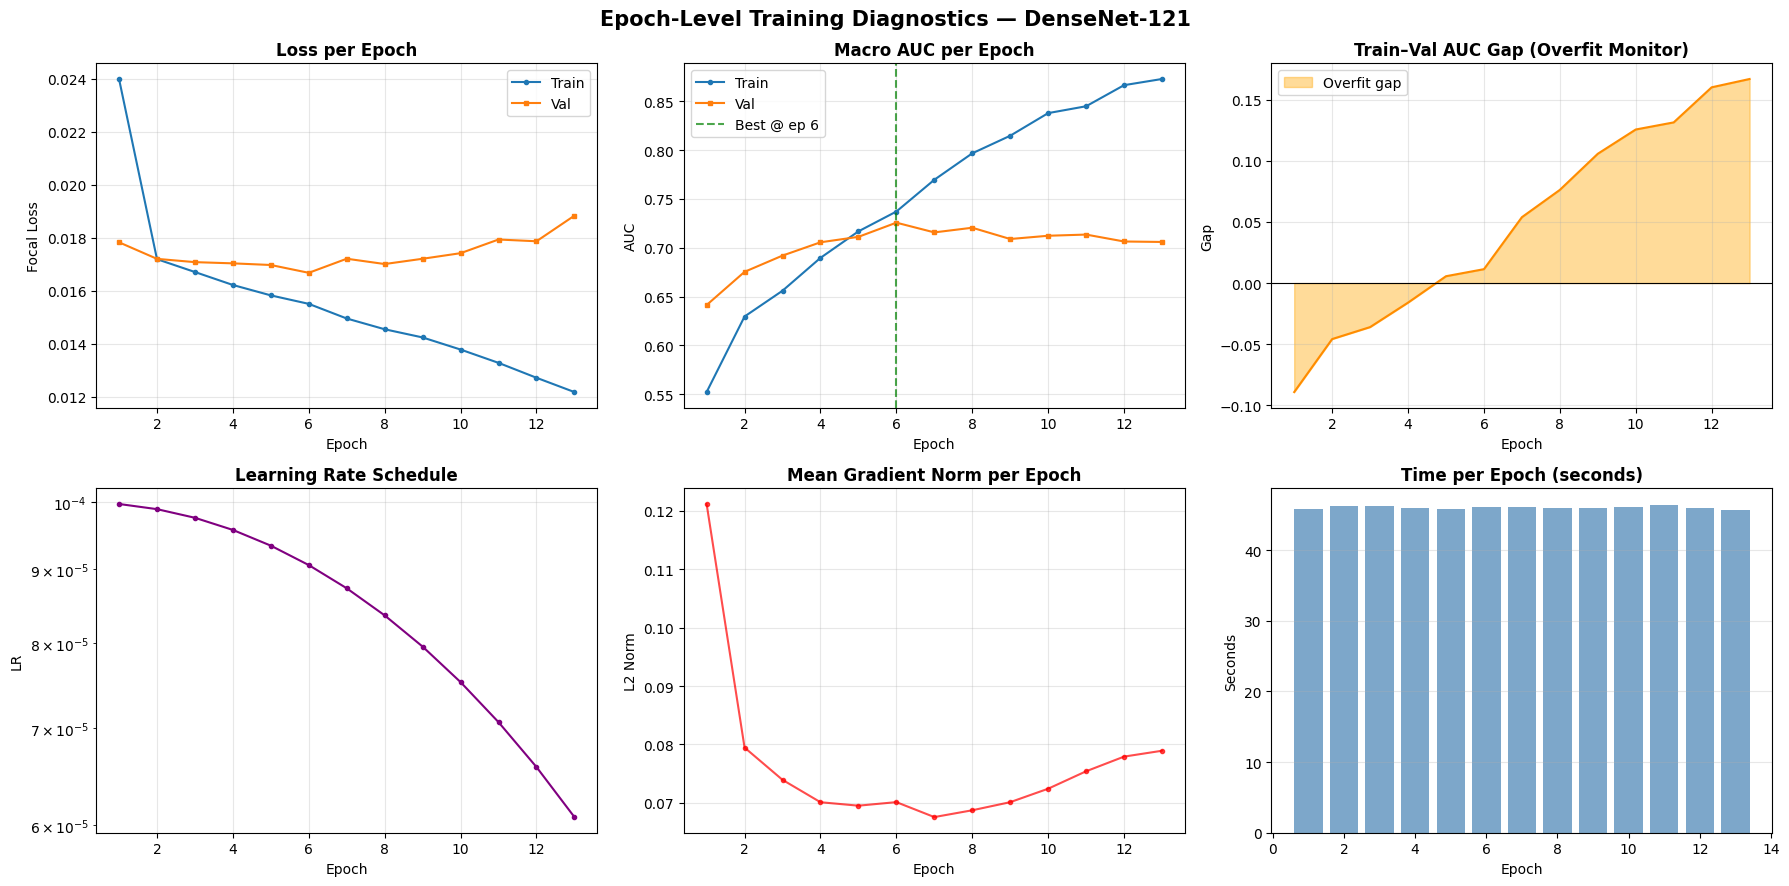

Epoch diagnostics saved.


In [26]:
# === EPOCH-LEVEL DIAGNOSTIC PLOTS ===
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
epochs_x = epoch_df['epoch'].values

# ── 1. Loss curves ────────────────────────────────────────────
axes[0,0].plot(epochs_x, epoch_df['train_loss'], label='Train', marker='o', markersize=3)
axes[0,0].plot(epochs_x, epoch_df['val_loss'],   label='Val',   marker='s', markersize=3)
axes[0,0].set_title('Loss per Epoch', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Focal Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# ── 2. AUC curves ─────────────────────────────────────────────
axes[0,1].plot(epochs_x, epoch_df['train_auc'], label='Train', marker='o', markersize=3)
axes[0,1].plot(epochs_x, epoch_df['val_auc'],   label='Val',   marker='s', markersize=3)
axes[0,1].axvline(tracker.best_epoch, color='green', linestyle='--', alpha=0.7,
                  label=f'Best @ ep {tracker.best_epoch}')
axes[0,1].set_title('Macro AUC per Epoch', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('AUC')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# ── 3. Train-Val AUC gap ───────────────────────────────────────
gap = epoch_df['train_auc'] - epoch_df['val_auc']
axes[0,2].fill_between(epochs_x, 0, gap, alpha=0.4, color='orange', label='Overfit gap')
axes[0,2].plot(epochs_x, gap, color='darkorange')
axes[0,2].axhline(0, color='black', linewidth=0.8)
axes[0,2].set_title('Train–Val AUC Gap (Overfit Monitor)', fontweight='bold')
axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Gap')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# ── 4. Learning rate schedule ────────────────────────────────
axes[1,0].plot(epochs_x, epoch_df['lr'], color='purple', marker='.')
axes[1,0].set_title('Learning Rate Schedule', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('LR')
axes[1,0].set_yscale('log'); axes[1,0].grid(alpha=0.3)

# ── 5. Gradient norm ─────────────────────────────────────────
axes[1,1].plot(epochs_x, epoch_df['grad_norm'], color='red', marker='.', alpha=0.7)
axes[1,1].set_title('Mean Gradient Norm per Epoch', fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('L2 Norm')
axes[1,1].grid(alpha=0.3)

# ── 6. Time per epoch ─────────────────────────────────────────
axes[1,2].bar(epochs_x, epoch_df['time_s'], color='steelblue', alpha=0.7)
axes[1,2].set_title('Time per Epoch (seconds)', fontweight='bold')
axes[1,2].set_xlabel('Epoch'); axes[1,2].set_ylabel('Seconds')
axes[1,2].grid(alpha=0.3, axis='y')

plt.suptitle('Epoch-Level Training Diagnostics — DenseNet-121',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'epoch_diagnostics.png', dpi=150)
plt.show()
print("Epoch diagnostics saved.")

In [27]:
# === CHECKPOINT INVENTORY ===
ckpt_files = sorted((CFG.OUTPUT_DIR / 'epoch_ckpts').glob('*.pth'))
print(f"Periodic checkpoints saved: {len(ckpt_files)}")
for f in ckpt_files:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}  ({size_mb:.1f} MB)")
best_ckpt = CFG.OUTPUT_DIR / 'densenet121_best.pth'
print(f"\nBest checkpoint : {best_ckpt.name}  "
      f"({best_ckpt.stat().st_size/1e6:.1f} MB)  "
      f"Val AUC={best_auc:.4f}")

Periodic checkpoints saved: 2
  ckpt_epoch_005.pth  (30.6 MB)
  ckpt_epoch_010.pth  (30.6 MB)

Best checkpoint : densenet121_best.pth  (30.6 MB)  Val AUC=0.7257


---
## 4.2. Metrics

### 4.2.1. Per-Class AUC

In [28]:
# === PER-CLASS AUC ===
model.load_state_dict(torch.load(CFG.OUTPUT_DIR / 'densenet121_best.pth'))
_, _, y_true, y_prob = evaluate(model, test_loader, criterion, CFG.DEVICE)

per_class_auc = {}
for i, label in enumerate(CFG.DISEASE_LABELS):
    try:
        auc = roc_auc_score(y_true[:, i], y_prob[:, i])
    except ValueError:
        auc = float('nan')
    per_class_auc[label] = auc

auc_df = pd.DataFrame.from_dict(per_class_auc, orient='index', columns=['AUC']).sort_values('AUC', ascending=False)
print(auc_df.to_string())
print(f"\nMacro AUC: {auc_df['AUC'].mean():.4f}")

                         AUC
Fibrosis            0.869670
Pneumothorax        0.855179
Edema               0.838950
Emphysema           0.835935
Consolidation       0.812868
Effusion            0.795474
Atelectasis         0.768965
Pleural_Thickening  0.724697
Nodule              0.714934
Pneumonia           0.712481
Mass                0.672554
Cardiomegaly        0.638706
Infiltration        0.615338
Hernia                   NaN

Macro AUC: 0.7581


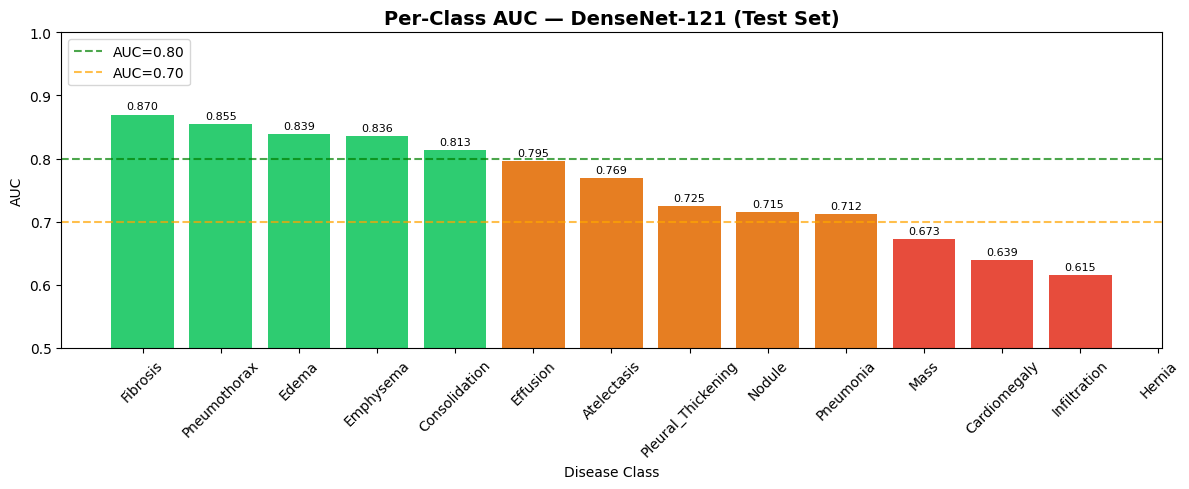

In [29]:
# === VISUALIZE PER-CLASS AUC ===
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v >= 0.80 else '#e67e22' if v >= 0.70 else '#e74c3c'
          for v in auc_df['AUC']]
bars = ax.bar(auc_df.index, auc_df['AUC'], color=colors)
ax.axhline(0.80, color='green',  linestyle='--', alpha=0.7, label='AUC=0.80')
ax.axhline(0.70, color='orange', linestyle='--', alpha=0.7, label='AUC=0.70')
ax.set_ylim(0.5, 1.0)
ax.set_title('Per-Class AUC — DenseNet-121 (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease Class')
ax.set_ylabel('AUC')
ax.tick_params(axis='x', rotation=45)
ax.legend()
for bar, val in zip(bars, auc_df['AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'per_class_auc.png', dpi=150)
plt.show()

### 4.2.2. Overall F1 Score

Best threshold (micro F1)  : 0.25  F1=0.2632
Best threshold (macro F1)  : 0.20  F1=0.1624


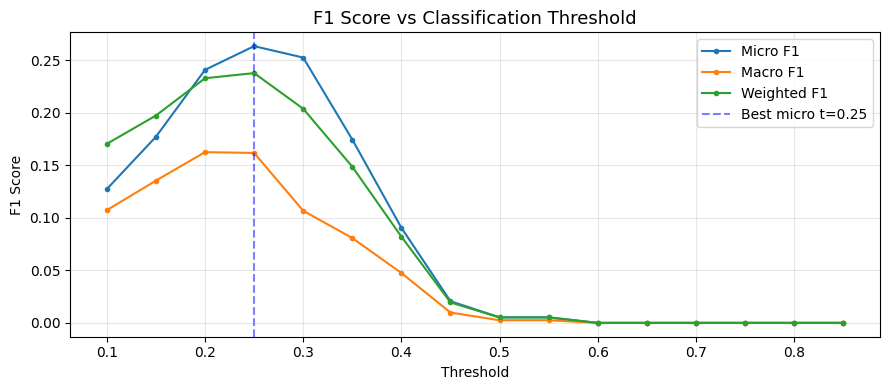

In [30]:
# === F1 SCORE ACROSS THRESHOLDS ===
thresholds = np.arange(0.1, 0.9, 0.05)
f1_micro, f1_macro, f1_weighted = [], [], []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_micro.append(f1_score(y_true, y_pred, average='micro', zero_division=0))
    f1_macro.append(f1_score(y_true, y_pred, average='macro', zero_division=0))
    f1_weighted.append(f1_score(y_true, y_pred, average='weighted', zero_division=0))

best_t_micro = thresholds[np.argmax(f1_micro)]
best_t_macro = thresholds[np.argmax(f1_macro)]
print(f"Best threshold (micro F1)  : {best_t_micro:.2f}  F1={max(f1_micro):.4f}")
print(f"Best threshold (macro F1)  : {best_t_macro:.2f}  F1={max(f1_macro):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_micro,    label='Micro F1',    marker='.')
ax.plot(thresholds, f1_macro,    label='Macro F1',    marker='.')
ax.plot(thresholds, f1_weighted, label='Weighted F1', marker='.')
ax.axvline(best_t_micro, color='blue',  linestyle='--', alpha=0.5, label=f'Best micro t={best_t_micro:.2f}')
ax.set_title('F1 Score vs Classification Threshold', fontsize=13)
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'f1_vs_threshold.png', dpi=150)
plt.show()

In [31]:
# Per-class F1 at best threshold
OPTIMAL_THRESHOLD = best_t_micro
y_pred_final = (y_prob >= OPTIMAL_THRESHOLD).astype(int)
print("Per-class Classification Report:")
print(classification_report(y_true, y_pred_final, target_names=CFG.DISEASE_LABELS, zero_division=0))

Per-class Classification Report:
                    precision    recall  f1-score   support

       Atelectasis       0.17      0.69      0.28        48
      Cardiomegaly       0.00      0.00      0.00        15
     Consolidation       0.13      0.15      0.14        26
             Edema       0.12      0.25      0.17        12
          Effusion       0.24      0.68      0.35        56
         Emphysema       0.14      0.20      0.17        10
          Fibrosis       0.00      0.00      0.00         6
            Hernia       0.00      0.00      0.00         0
      Infiltration       0.18      0.59      0.28        91
              Mass       0.18      0.22      0.20        32
            Nodule       0.14      0.21      0.17        29
Pleural_Thickening       0.14      0.29      0.19        17
         Pneumonia       0.00      0.00      0.00         7
      Pneumothorax       0.22      0.57      0.32        30

         micro avg       0.19      0.45      0.26       379
     

### 4.2.3. Confusion Matrices

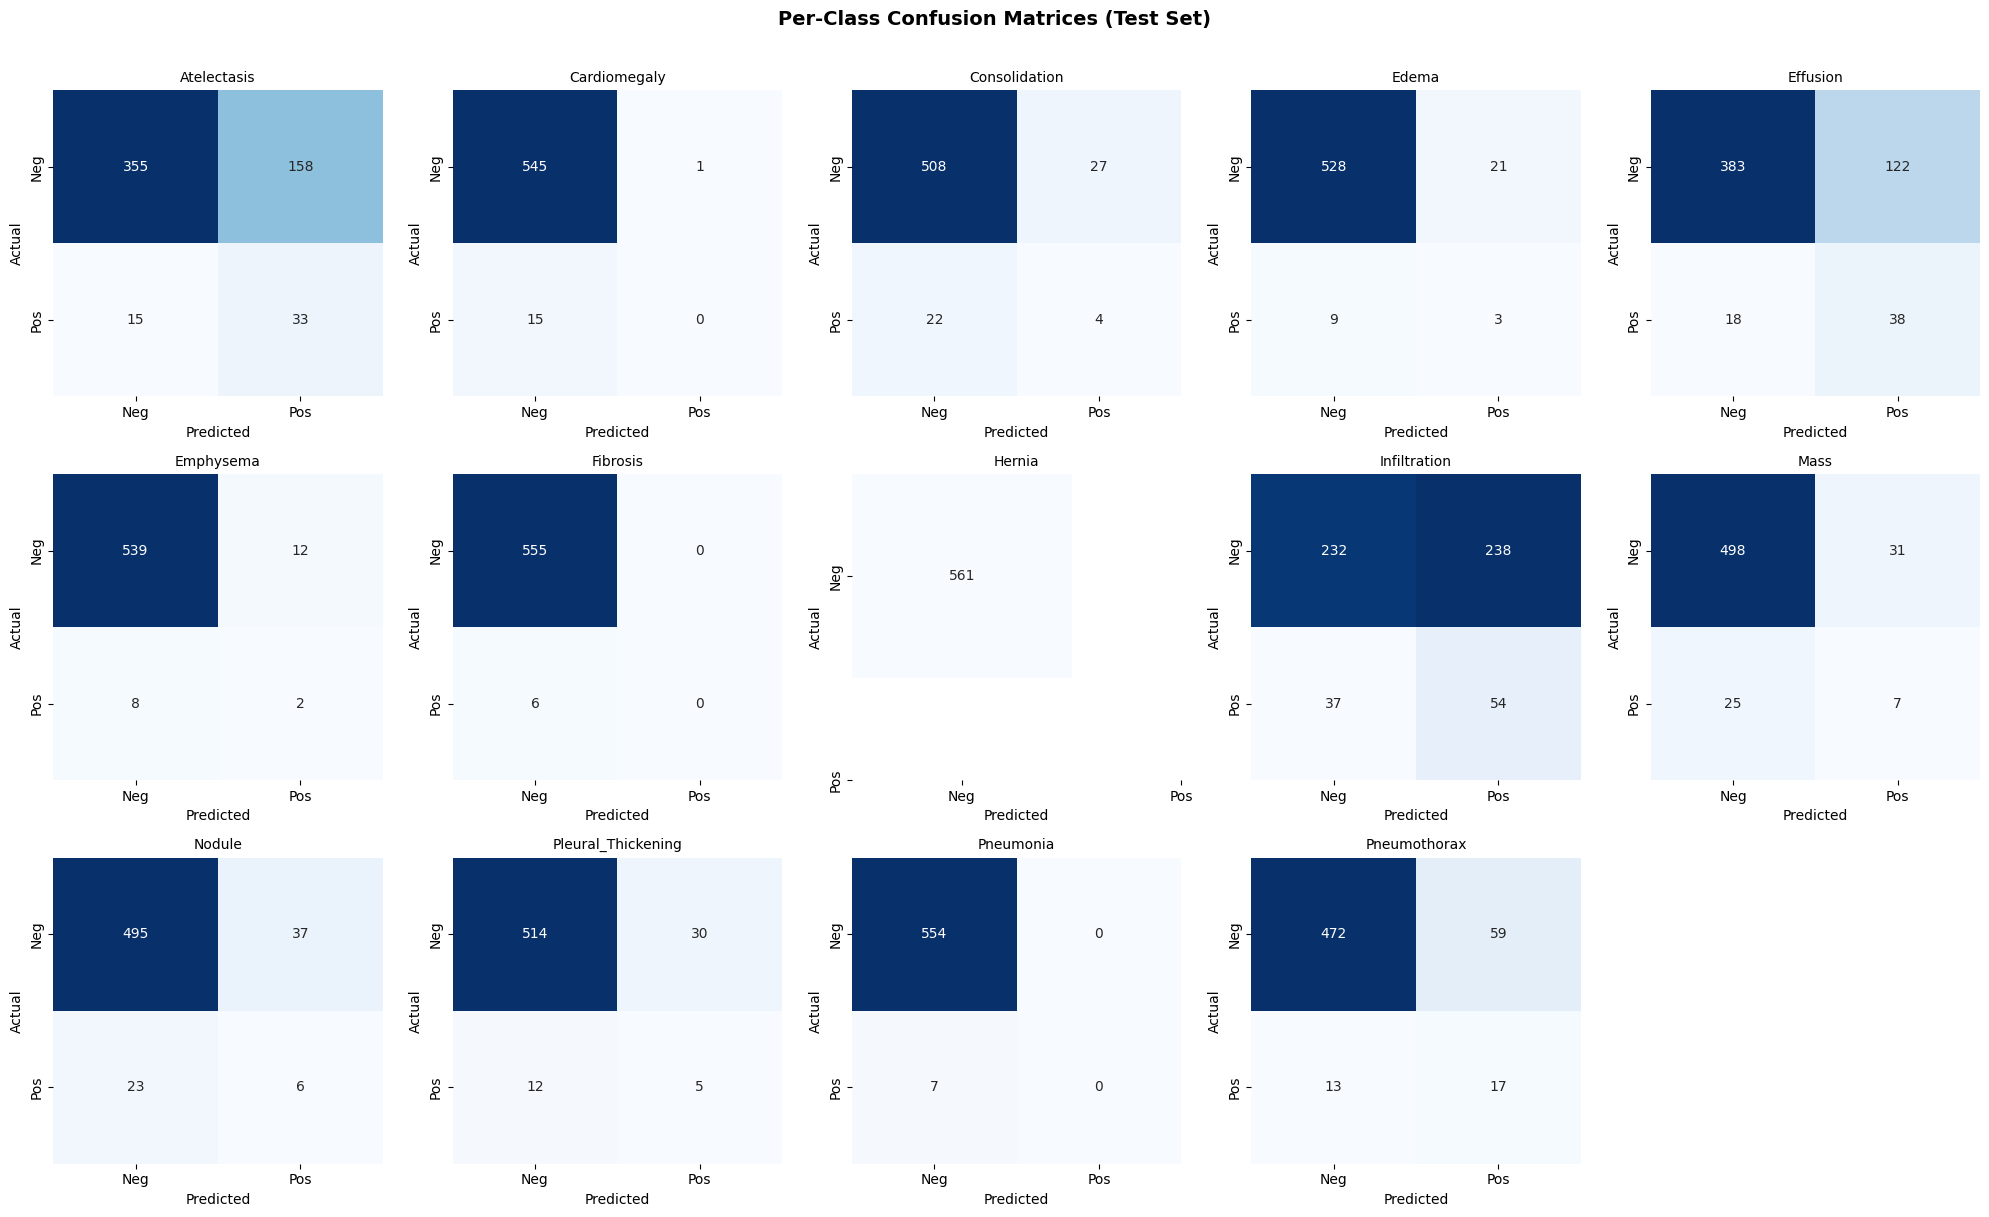

In [32]:
# === PER-CLASS CONFUSION MATRICES ===
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flat
for i, label in enumerate(CFG.DISEASE_LABELS):
    cm = confusion_matrix(y_true[:, i], y_pred_final[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i], xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                cbar=False)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
# Hide the last (empty) subplot
axes[-1].axis('off')
plt.suptitle('Per-Class Confusion Matrices (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.2.4. Inference

This section covers **everything needed to deploy the trained model**: loading a checkpoint, running single-image and batch inference, applying per-class thresholds, generating a human-readable report, and benchmarking inference speed.

In [33]:
# === INFERENCE SETUP ===
# Load the best checkpoint into a fresh model instance.

def load_model_for_inference(checkpoint_path, device=CFG.DEVICE):
    """Load a saved DenseNet-121 checkpoint, set to eval mode."""
    inf_model = build_densenet121().to(device)
    inf_model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )
    inf_model.eval()
    print(f"Model loaded from: {checkpoint_path}")
    return inf_model

inf_model = load_model_for_inference(CFG.OUTPUT_DIR / 'densenet121_best.pth')

Model loaded from: /kaggle/working/densenet121_best.pth


In [34]:
# === SINGLE-IMAGE INFERENCE ===

def predict_single(image_path, model, threshold=OPTIMAL_THRESHOLD,
                   device=CFG.DEVICE, transform=None):
    """
    Run inference on a single chest X-ray image.

    Returns
    -------
    dict with keys:
        probs      : np.ndarray of shape (14,) — per-class probabilities
        labels     : list[str]  — predicted disease labels above threshold
        confidence : dict[str, float] — label → probability for positives
    """
    if transform is None:
        transform = val_transforms

    img = np.array(Image.open(image_path).convert('RGB'))
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.sigmoid(logits).cpu().numpy()[0]  # shape (14,)

    predicted_labels = [
        CFG.DISEASE_LABELS[i]
        for i, p in enumerate(probs) if p >= threshold
    ]
    confidence = {CFG.DISEASE_LABELS[i]: float(probs[i])
                  for i, p in enumerate(probs) if p >= threshold}

    return {'probs': probs, 'labels': predicted_labels, 'confidence': confidence}


def print_prediction_report(image_path, result, ground_truth_labels=None):
    """Pretty-print a single-image prediction report."""
    print("="*55)
    print(f" INFERENCE REPORT")
    print(f" Image  : {Path(image_path).name}")
    print("="*55)
    if ground_truth_labels is not None:
        print(f" Ground Truth   : {ground_truth_labels if ground_truth_labels else ['No Finding']}")
    print(f" Predicted Dxs  : {result['labels'] if result['labels'] else ['No Finding']}")
    print()
    print(f" {'Disease':<25}  {'Prob':>6}  {'Flag'}")
    print(f" {'-'*25}  {'-'*6}  {'-'*4}")
    for label, prob in sorted(zip(CFG.DISEASE_LABELS, result['probs']),
                               key=lambda x: -x[1]):
        flag = '⚠ POSITIVE' if label in result['labels'] else ''
        bar  = '█' * int(prob * 20)
        print(f" {label:<25}  {prob:>6.3f}  {flag}  {bar}")
    print("="*55)

# --- Demo on a sample test image ---
sample_idx  = 0
sample_row  = test_df.iloc[sample_idx]
img_path    = CFG.IMAGE_DIR / sample_row['Image Index']
gt_labels   = sample_row['labels']

result = predict_single(img_path, inf_model)
print_prediction_report(img_path, result, ground_truth_labels=gt_labels)

 INFERENCE REPORT
 Image  : 00014750_000.png
 Ground Truth   : ['No Finding']
 Predicted Dxs  : ['No Finding']

 Disease                      Prob  Flag
 -------------------------  ------  ----
 Infiltration                0.249    ████
 Mass                        0.189    ███
 Nodule                      0.182    ███
 Atelectasis                 0.161    ███
 Pleural_Thickening          0.129    ██
 Emphysema                   0.124    ██
 Pneumothorax                0.108    ██
 Fibrosis                    0.108    ██
 Cardiomegaly                0.106    ██
 Effusion                    0.105    ██
 Pneumonia                   0.085    █
 Consolidation               0.083    █
 Edema                       0.067    █
 Hernia                      0.061    █


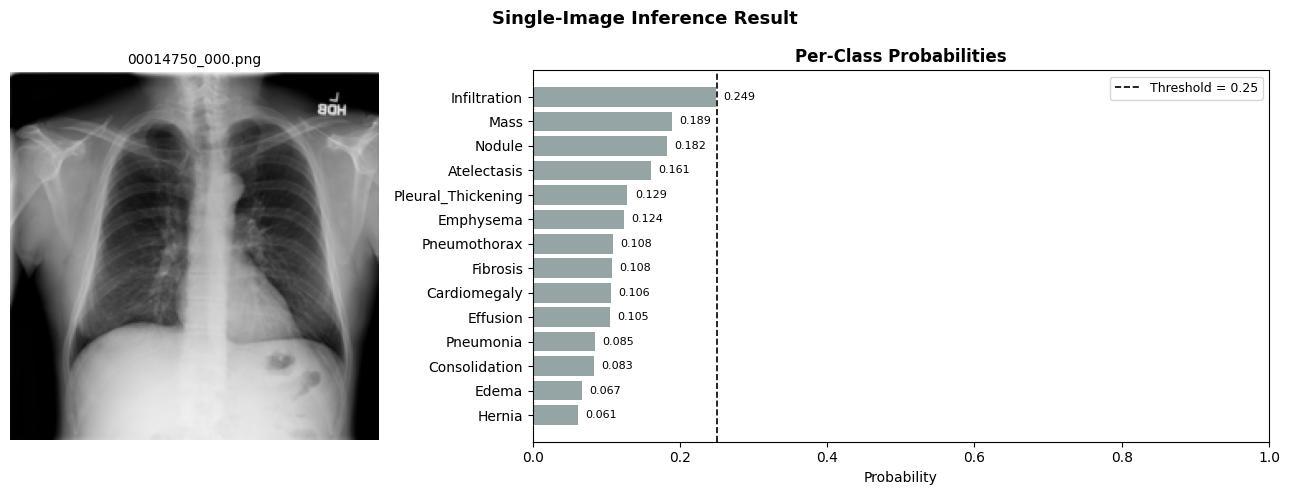

In [35]:
# === VISUALISE SINGLE-IMAGE INFERENCE ===

def visualise_prediction(image_path, result):
    img = np.array(Image.open(image_path).convert('RGB').resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(13, 5),
                                          gridspec_kw={'width_ratios': [1, 2]})

    # ── Left: X-ray image ────────────────────────────────────
    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(f"{Path(image_path).name}", fontsize=10)
    ax_img.axis('off')
    diagnosis = ', '.join(result['labels']) if result['labels'] else 'No Finding'
    ax_img.set_xlabel(f"Prediction: {diagnosis}", fontsize=9, color='red' if result['labels'] else 'green')

    # ── Right: Probability bar chart ─────────────────────────
    sorted_pairs = sorted(zip(CFG.DISEASE_LABELS, result['probs']), key=lambda x: -x[1])
    names, probs = zip(*sorted_pairs)
    colors = ['#e74c3c' if n in result['labels'] else '#95a5a6' for n in names]
    bars = ax_bar.barh(names, probs, color=colors)
    ax_bar.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--',
                   linewidth=1.2, label=f'Threshold = {OPTIMAL_THRESHOLD:.2f}')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title('Per-Class Probabilities', fontweight='bold')
    ax_bar.set_xlabel('Probability')
    ax_bar.legend(fontsize=9)
    for bar, val in zip(bars, probs):
        ax_bar.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax_bar.invert_yaxis()

    plt.suptitle('Single-Image Inference Result', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG.OUTPUT_DIR / 'inference_sample.png', dpi=150)
    plt.show()

visualise_prediction(img_path, result)

In [36]:
# === BATCH INFERENCE ===
# Run inference over the entire test set and collect results.

def batch_inference(model, dataloader, device=CFG.DEVICE):
    """
    Run inference over a DataLoader.
    Returns:
        probs   : np.ndarray (N, 14) — sigmoid probabilities
        targets : np.ndarray (N, 14) — ground-truth labels (0/1)
    """
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc='Batch Inference'):
            images = images.to(device, non_blocking=True)
            logits = model(images)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return np.vstack(all_probs), np.vstack(all_targets)

test_probs_inf, test_targets_inf = batch_inference(inf_model, test_loader)
print(f"Inference complete. Output shape: {test_probs_inf.shape}")
print(f"Mean predicted probability per class (top 5):")
mean_probs = test_probs_inf.mean(axis=0)
top5 = np.argsort(mean_probs)[::-1][:5]
for idx in top5:
    print(f"  {CFG.DISEASE_LABELS[idx]:<25}  {mean_probs[idx]:.4f}")

Batch Inference: 100%|██████████| 18/18 [00:04<00:00,  3.68it/s]

Inference complete. Output shape: (561, 14)
Mean predicted probability per class (top 5):
  Infiltration               0.2568
  Atelectasis                0.2113
  Effusion                   0.1870
  Nodule                     0.1793
  Mass                       0.1705


In [37]:
# === PER-CLASS THRESHOLD TUNING FOR INFERENCE ===
# Rather than a single global threshold, find the optimal threshold per class.

def tune_thresholds_per_class(y_true, y_prob,
                               candidates=np.arange(0.1, 0.9, 0.02)):
    """
    For each class, find the threshold that maximises F1 on the provided split.
    In production, tune on the VALIDATION set and apply to test set.
    """
    best_thresholds = {}
    for i, label in enumerate(CFG.DISEASE_LABELS):
        best_t, best_f1 = 0.5, 0.0
        for t in candidates:
            pred = (y_prob[:, i] >= t).astype(int)
            f1   = f1_score(y_true[:, i], pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresholds[label] = round(best_t, 2)
    return best_thresholds

# Tune on validation set (correct practice)
val_probs_inf, val_targets_inf = batch_inference(inf_model, val_loader)
per_class_thresholds = tune_thresholds_per_class(val_targets_inf, val_probs_inf)

print("Optimal per-class thresholds (tuned on val set):")
for label, t in per_class_thresholds.items():
    print(f"  {label:<25}  threshold={t:.2f}")

Batch Inference: 100%|██████████| 18/18 [00:04<00:00,  3.66it/s]


Optimal per-class thresholds (tuned on val set):
  Atelectasis                threshold=0.32
  Cardiomegaly               threshold=0.20
  Consolidation              threshold=0.20
  Edema                      threshold=0.24
  Effusion                   threshold=0.26
  Emphysema                  threshold=0.20
  Fibrosis                   threshold=0.20
  Hernia                     threshold=0.50
  Infiltration               threshold=0.24
  Mass                       threshold=0.24
  Nodule                     threshold=0.24
  Pleural_Thickening         threshold=0.18
  Pneumonia                  threshold=0.16
  Pneumothorax               threshold=0.28


In [38]:
# === APPLY PER-CLASS THRESHOLDS TO TEST SET ===

def apply_per_class_thresholds(probs, thresholds_dict):
    """Convert probabilities to binary predictions using per-class thresholds."""
    preds = np.zeros_like(probs, dtype=int)
    for i, label in enumerate(CFG.DISEASE_LABELS):
        preds[:, i] = (probs[:, i] >= thresholds_dict[label]).astype(int)
    return preds

y_pred_per_class = apply_per_class_thresholds(test_probs_inf, per_class_thresholds)
y_pred_global    = (test_probs_inf >= OPTIMAL_THRESHOLD).astype(int)

f1_global    = f1_score(test_targets_inf, y_pred_global,    average='macro', zero_division=0)
f1_per_class = f1_score(test_targets_inf, y_pred_per_class, average='macro', zero_division=0)

print(f"Macro F1 — Global threshold ({OPTIMAL_THRESHOLD:.2f})  : {f1_global:.4f}")
print(f"Macro F1 — Per-class thresholds              : {f1_per_class:.4f}")
print(f"Improvement from per-class tuning            : +{f1_per_class - f1_global:.4f}")

Macro F1 — Global threshold (0.25)  : 0.1617
Macro F1 — Per-class thresholds              : 0.1719
Improvement from per-class tuning            : +0.0102


In [39]:
# === INFERENCE SPEED BENCHMARK ===

import time

def benchmark_inference(model, input_size=(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE),
                         n_runs=50, device=CFG.DEVICE):
    """
    Measure average single-image inference latency and throughput.
    Warms up GPU before timing.
    """
    dummy_input = torch.randn(input_size).to(device)
    model.eval()

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(dummy_input)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

    mean_ms  = np.mean(times)  * 1000
    std_ms   = np.std(times)   * 1000
    fps      = 1.0 / np.mean(times)
    return mean_ms, std_ms, fps

# Single image
mean_1, std_1, fps_1 = benchmark_inference(inf_model, (1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE))
print(f"Single-image inference  : {mean_1:.2f} ± {std_1:.2f} ms  ({fps_1:.0f} FPS)")

# Batch of 32
mean_32, std_32, fps_32 = benchmark_inference(inf_model, (32, 3, CFG.IMG_SIZE, CFG.IMG_SIZE))
print(f"Batch-32   inference    : {mean_32:.2f} ± {std_32:.2f} ms  ({fps_32*32:.0f} imgs/sec)")

print(f"\nDevice: {CFG.DEVICE.upper()}")
if CFG.DEVICE == 'cuda':
    memory_stats()

Single-image inference  : 18.00 ± 0.79 ms  (56 FPS)
Batch-32   inference    : 90.96 ± 0.36 ms  (352 imgs/sec)

Device: CUDA
GPU Memory | Allocated: 0.52GB | Reserved: 1.16GB | Total: 15.64GB


Set CUSTOM_IMAGE_PATH to a .png/.jpg chest X-ray to run custom inference.
Falling back to a random test-set sample...
 INFERENCE REPORT
 Image  : 00009842_003.png
 Ground Truth   : ['No Finding']
 Predicted Dxs  : ['Infiltration']

 Disease                      Prob  Flag
 -------------------------  ------  ----
 Infiltration                0.324  ⚠ POSITIVE  ██████
 Mass                        0.170    ███
 Nodule                      0.145    ██
 Atelectasis                 0.114    ██
 Pleural_Thickening          0.093    █
 Pneumothorax                0.092    █
 Fibrosis                    0.089    █
 Cardiomegaly                0.082    █
 Effusion                    0.080    █
 Consolidation               0.080    █
 Emphysema                   0.064    █
 Pneumonia                   0.061    █
 Edema                       0.053    █
 Hernia                      0.041    


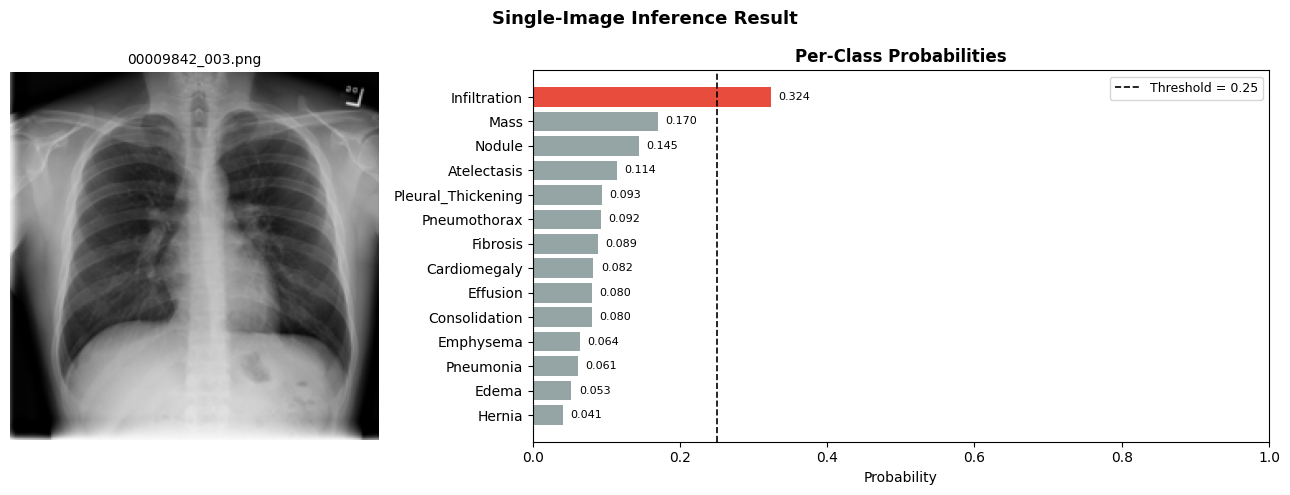

In [40]:
# === INFERENCE ON CUSTOM / UNSEEN IMAGE ===
# Drop any new chest X-ray file into the path below to get an instant report.

CUSTOM_IMAGE_PATH = None   # e.g. Path('/kaggle/input/my-xray/patient001.png')

if CUSTOM_IMAGE_PATH and Path(CUSTOM_IMAGE_PATH).exists():
    custom_result = predict_single(CUSTOM_IMAGE_PATH, inf_model)
    print_prediction_report(CUSTOM_IMAGE_PATH, custom_result)
    visualise_prediction(CUSTOM_IMAGE_PATH, custom_result)
else:
    print("Set CUSTOM_IMAGE_PATH to a .png/.jpg chest X-ray to run custom inference.")
    print("Falling back to a random test-set sample...")
    rand_idx   = np.random.randint(0, len(test_df))
    rand_row   = test_df.iloc[rand_idx]
    rand_path  = CFG.IMAGE_DIR / rand_row['Image Index']
    rand_result= predict_single(rand_path, inf_model)
    print_prediction_report(rand_path, rand_result,
                             ground_truth_labels=rand_row['labels'])
    visualise_prediction(rand_path, rand_result)

---
## 4.3. Experiments

### 4.3.1. Architecture Comparison

In [41]:
# === ARCHITECTURE COMPARISON ===
# NOTE: Experiments use isolated variables — original model object is untouched.

def run_experiment(model_fn, name, epochs=5):
    """Quick 5-epoch probe on the validation set for comparison."""
    exp_model    = model_fn().to(CFG.DEVICE)
    exp_criterion = FocalLoss()
    exp_optimizer = optim.AdamW(exp_model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    exp_scaler    = torch.cuda.amp.GradScaler() if CFG.DEVICE == 'cuda' else None
    results = []
    for ep in range(1, epochs+1):
        tl, ta = train_one_epoch(exp_model, train_loader, exp_optimizer, exp_criterion, CFG.DEVICE, exp_scaler)
        vl, va, _, _ = evaluate(exp_model, val_loader, exp_criterion, CFG.DEVICE)
        results.append({'epoch': ep, 'val_auc': va, 'val_loss': vl})
        print(f"  [{name}] Epoch {ep}/{epochs}  Val AUC: {va:.4f}")
        free_memory()
    return pd.DataFrame(results)

# Run architecture comparison
arch_results = {}
arch_results['DenseNet-121'] = run_experiment(build_densenet121, 'DenseNet-121', epochs=5)
arch_results['ViT-B/16']     = run_experiment(build_vit,          'ViT-B/16',     epochs=5)
free_memory()

  [DenseNet-121] Epoch 1/5  Val AUC: 0.6635


  [DenseNet-121] Epoch 2/5  Val AUC: 0.7104


  [DenseNet-121] Epoch 3/5  Val AUC: 0.7168


  [DenseNet-121] Epoch 4/5  Val AUC: 0.7249


  [DenseNet-121] Epoch 5/5  Val AUC: 0.7272


  [ViT-B/16] Epoch 1/5  Val AUC: 0.5974


  [ViT-B/16] Epoch 2/5  Val AUC: 0.5658


  [ViT-B/16] Epoch 3/5  Val AUC: 0.6166


  [ViT-B/16] Epoch 4/5  Val AUC: 0.6506


  [ViT-B/16] Epoch 5/5  Val AUC: 0.6462


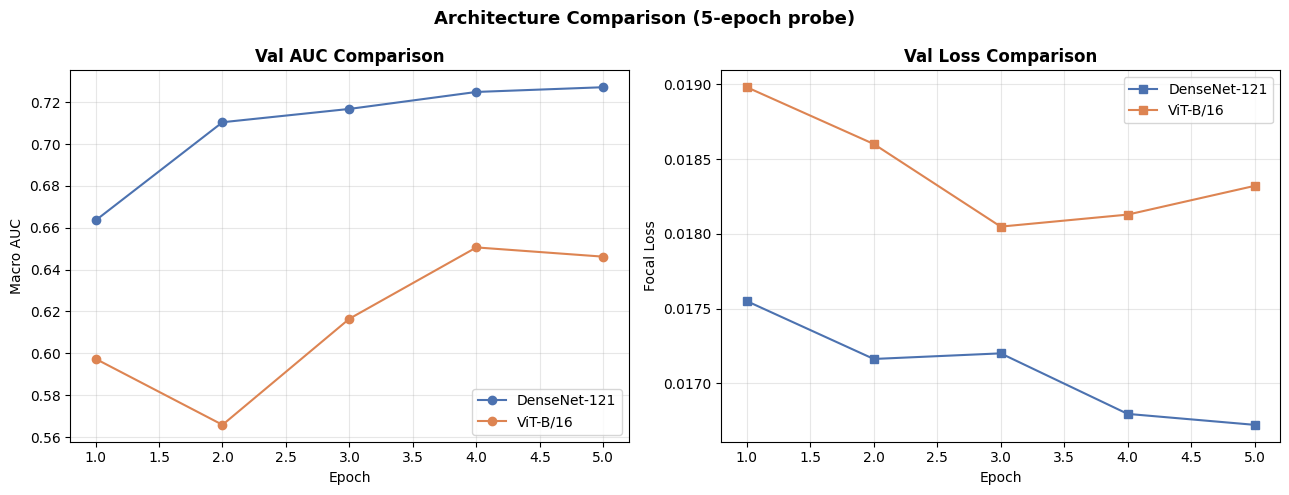

DenseNet-121          Best Val AUC: 0.7272
ViT-B/16              Best Val AUC: 0.6506


In [42]:
# === VISUALIZE ARCHITECTURE COMPARISON ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'DenseNet-121': '#4C72B0', 'ViT-B/16': '#DD8452'}

for arch, res in arch_results.items():
    axes[0].plot(res['epoch'], res['val_auc'],  label=arch, color=colors[arch], marker='o')
    axes[1].plot(res['epoch'], res['val_loss'], label=arch, color=colors[arch], marker='s')

for ax, title, ylabel in zip(axes,
                              ['Val AUC Comparison', 'Val Loss Comparison'],
                              ['Macro AUC', 'Focal Loss']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Architecture Comparison (5-epoch probe)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'arch_comparison.png', dpi=150)
plt.show()

for arch, res in arch_results.items():
    print(f"{arch:20s}  Best Val AUC: {res['val_auc'].max():.4f}")

### 4.3.2. Data Augmentation Ablation

In [43]:
# === AUGMENTATION ABLATION ===
# Compare: No augmentation vs Basic (flip+rotate) vs Full augmentation

no_aug_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=CFG.MEAN, std=CFG.STD),
    ToTensorV2(),
])

basic_aug_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Normalize(mean=CFG.MEAN, std=CFG.STD),
    ToTensorV2(),
])

aug_configs = {
    'No Augmentation' : no_aug_transforms,
    'Basic (flip+rot)': basic_aug_transforms,
    'Full Augmentation': train_transforms,
}

aug_results = {}
for aug_name, aug_tfm in aug_configs.items():
    print(f"\n--- {aug_name} ---")
    aug_train_ds = ChestXrayDataset(train_df, CFG.IMAGE_DIR, aug_tfm)
    aug_loader   = DataLoader(aug_train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                              num_workers=CFG.NUM_WORKERS, pin_memory=True)
    aug_model     = build_densenet121().to(CFG.DEVICE)
    aug_criterion = FocalLoss()
    aug_optimizer = optim.AdamW(aug_model.parameters(), lr=CFG.LR)
    aug_scaler    = torch.cuda.amp.GradScaler() if CFG.DEVICE == 'cuda' else None
    ep_results = []
    for ep in range(1, 6):
        tl, ta = train_one_epoch(aug_model, aug_loader, aug_optimizer, aug_criterion, CFG.DEVICE, aug_scaler)
        vl, va, _, _ = evaluate(aug_model, val_loader, aug_criterion, CFG.DEVICE)
        ep_results.append({'epoch': ep, 'val_auc': va})
        print(f"  Epoch {ep}/5  Val AUC: {va:.4f}")
        free_memory()
    aug_results[aug_name] = pd.DataFrame(ep_results)


--- No Augmentation ---


  Epoch 1/5  Val AUC: 0.6722


  Epoch 2/5  Val AUC: 0.6858


  Epoch 3/5  Val AUC: 0.6846


  Epoch 4/5  Val AUC: 0.6879


...

  Epoch 1/5  Val AUC: 0.6575


  Epoch 2/5  Val AUC: 0.7097


  Epoch 3/5  Val AUC: 0.7119


  Epoch 4/5  Val AUC: 0.7350


  Epoch 5/5  Val AUC: 0.7337


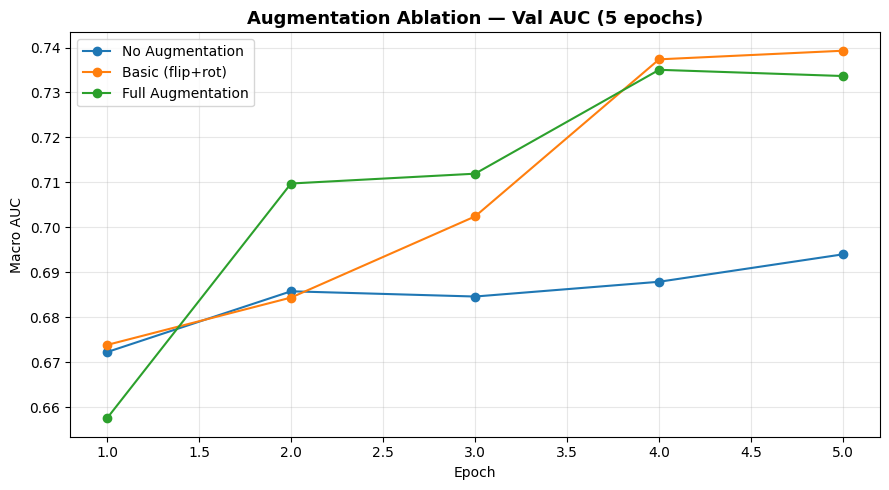

No Augmentation                 Final Val AUC: 0.6940
Basic (flip+rot)                Final Val AUC: 0.7393
Full Augmentation               Final Val AUC: 0.7337


In [44]:
# === VISUALIZE AUGMENTATION ABLATION ===
fig, ax = plt.subplots(figsize=(9, 5))
for aug_name, res in aug_results.items():
    ax.plot(res['epoch'], res['val_auc'], marker='o', label=aug_name)
ax.set_title('Augmentation Ablation — Val AUC (5 epochs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'augmentation_ablation.png', dpi=150)
plt.show()

for k, v in aug_results.items():
    print(f"{k:30s}  Final Val AUC: {v['val_auc'].iloc[-1]:.4f}")

### 4.3.3. Adversarial Training (FGSM)

In [45]:
# === FGSM ADVERSARIAL TRAINING ===
# FGSM: x_adv = x + epsilon * sign(grad_x(Loss))
# Isolated experiment — uses its own model copy.

EPS = 0.01  # perturbation magnitude (small for medical images)

def fgsm_attack(images, targets, model, criterion, eps=EPS):
    """Generate FGSM adversarial examples."""
    images = images.clone().requires_grad_(True)
    logits = model(images)
    loss   = criterion(logits, targets)
    model.zero_grad()
    loss.backward()
    perturbed = images + eps * images.grad.sign()
    return perturbed.detach()

def train_one_epoch_adv(model, loader, optimizer, criterion, device, eps=EPS, adv_ratio=0.5):
    """Training with mixed clean + adversarial batches."""
    model.train()
    total_loss = 0.0
    all_targets, all_probs = [], []

    for images, targets in tqdm(loader, desc='Adv Train', leave=False):
        images  = images.to(device)
        targets = targets.to(device)

        # Mix clean and adversarial
        if random.random() < adv_ratio:
            images = fgsm_attack(images, targets, model, criterion, eps)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss  += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    avg_loss    = total_loss / len(loader.dataset)
    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    auc = roc_auc_score(all_targets, all_probs, average='macro')
    return avg_loss, auc

print("Training adversarially-augmented model (5 epochs)...")
adv_model     = build_densenet121().to(CFG.DEVICE)
adv_criterion = FocalLoss()
adv_optimizer = optim.AdamW(adv_model.parameters(), lr=CFG.LR)
adv_results   = []

for ep in range(1, 6):
    tl, ta = train_one_epoch_adv(adv_model, train_loader, adv_optimizer, adv_criterion, CFG.DEVICE)
    vl, va, _, _ = evaluate(adv_model, val_loader, adv_criterion, CFG.DEVICE)
    adv_results.append({'epoch': ep, 'val_auc': va, 'train_auc': ta})
    print(f"  Epoch {ep}/5  Train AUC: {ta:.4f}  Val AUC: {va:.4f}")
    free_memory()

adv_df = pd.DataFrame(adv_results)

Training adversarially-augmented model (5 epochs)...


  Epoch 1/5  Train AUC: 0.4204  Val AUC: 0.6321


  Epoch 2/5  Train AUC: 0.4616  Val AUC: 0.6666


  Epoch 3/5  Train AUC: 0.5057  Val AUC: 0.6820


  Epoch 4/5  Train AUC: 0.5256  Val AUC: 0.6805


  Epoch 5/5  Train AUC: 0.5536  Val AUC: 0.6909


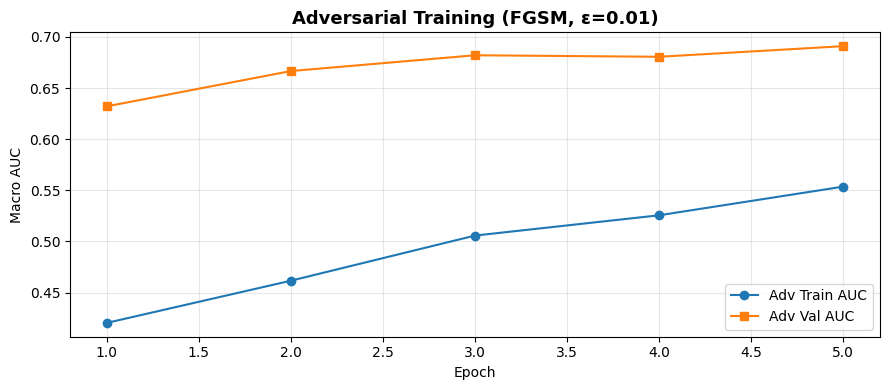

Standard model best val AUC : 0.7257
Adversarial model best val AUC: 0.6909


In [46]:
# === VISUALIZE ADVERSARIAL TRAINING ===
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(adv_df['epoch'], adv_df['train_auc'], label='Adv Train AUC', marker='o')
ax.plot(adv_df['epoch'], adv_df['val_auc'],   label='Adv Val AUC',   marker='s')
ax.set_title('Adversarial Training (FGSM, ε=0.01)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'adversarial_training.png', dpi=150)
plt.show()
print(f"Standard model best val AUC : {best_auc:.4f}")
print(f"Adversarial model best val AUC: {adv_df['val_auc'].max():.4f}")

---
# 5. Interpretability — GradCAM Saliency Maps

In [47]:
# === GRADCAM ===
# Manual implementation compatible with DenseNet-121.

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        logits = self.model(input_tensor)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        pooled_grads = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (pooled_grads * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Hook into the last dense block
target_layer = model.features.denseblock4.denselayer16.conv2  # DenseNet-121 last conv
gradcam = GradCAM(model, target_layer)
print("GradCAM initialized on DenseNet-121 last dense block.")

GradCAM initialized on DenseNet-121 last dense block.


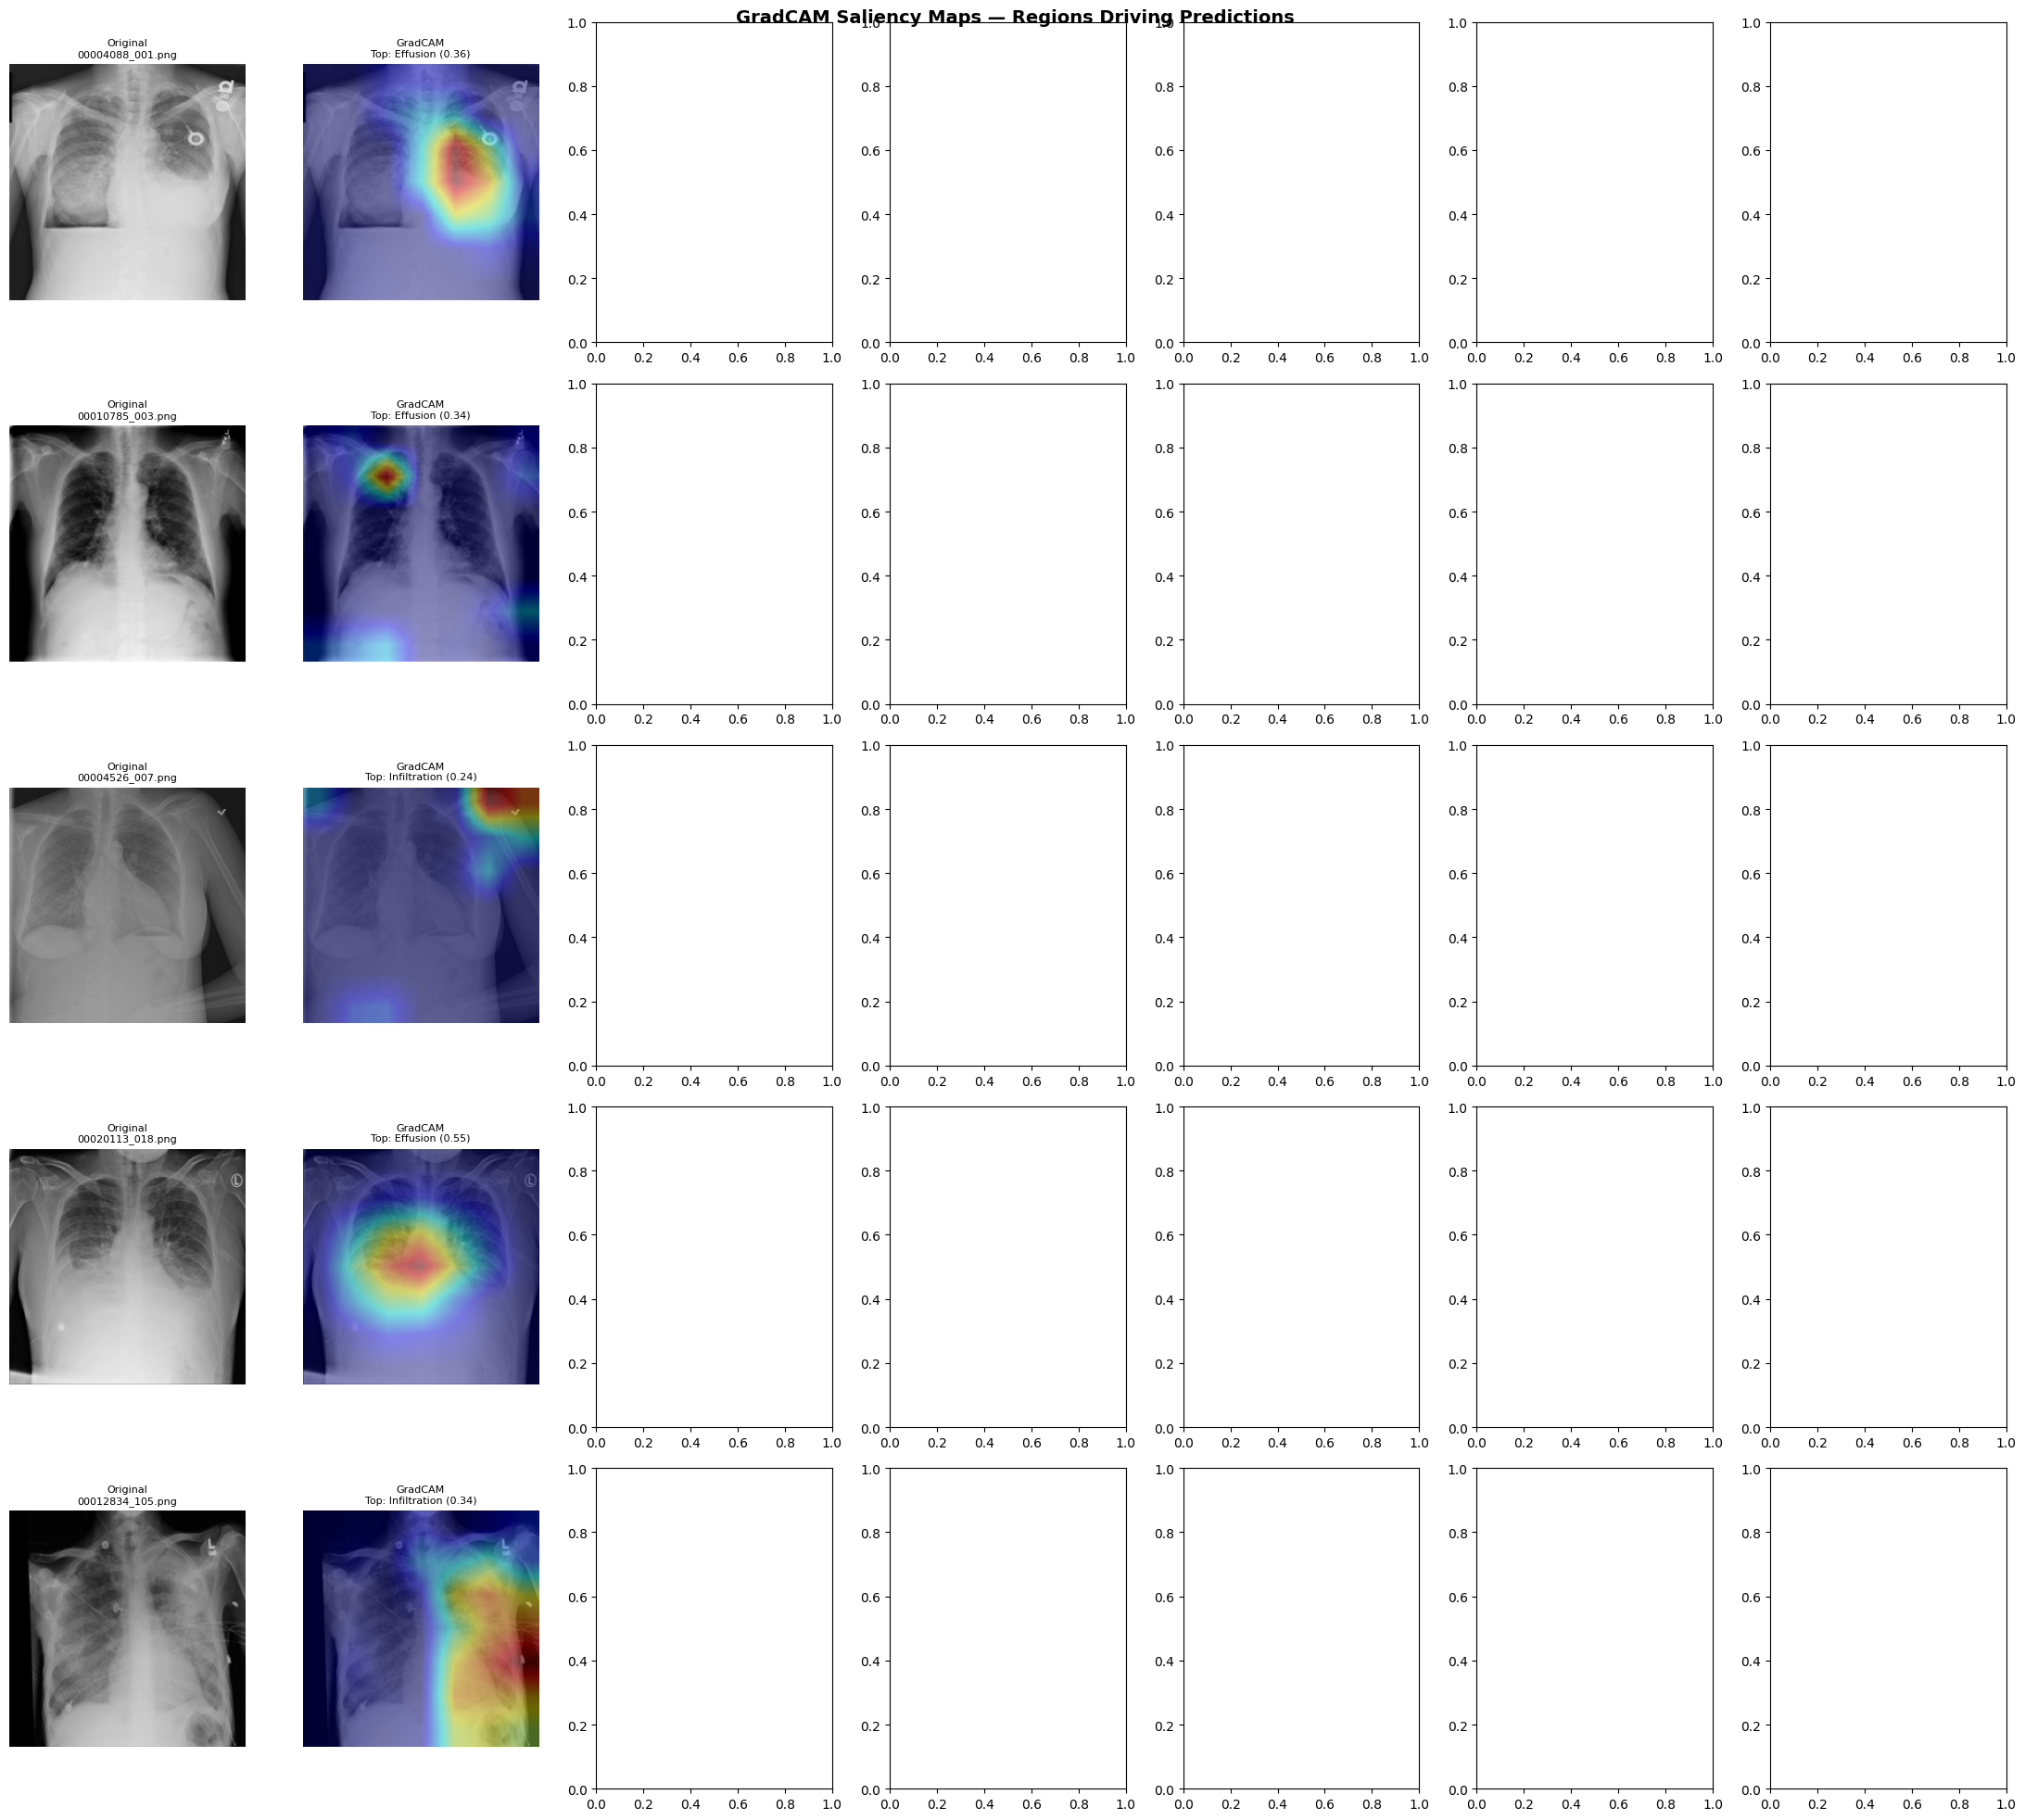

In [48]:
# === VISUALIZE SALIENCY MAPS ===
import cv2

def overlay_cam(img_np, cam, alpha=0.4):
    """Overlay GradCAM heatmap on original image."""
    heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay  = np.float32(img_np) * (1 - alpha) + np.float32(heatmap) * alpha
    return np.uint8(np.clip(overlay, 0, 255))

# Pick N test images with positive labels for visualization
N_SAMPLES = 5
vis_indices = [i for i in range(len(test_df)) if test_df[CFG.DISEASE_LABELS].iloc[i].sum() > 0][:N_SAMPLES]

fig, axes = plt.subplots(N_SAMPLES, CFG.NUM_CLASSES // 2, figsize=(22, N_SAMPLES * 4))
for row, idx in enumerate(vis_indices):
    img_path = CFG.IMAGE_DIR / test_df.loc[idx, 'Image Index']
    orig_img = np.array(Image.open(img_path).convert('RGB').resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))
    transform_val = val_transforms(image=orig_img)['image'].unsqueeze(0).to(CFG.DEVICE)

    with torch.no_grad():
        probs = torch.sigmoid(model(transform_val)).cpu().numpy()[0]

    # Get top predicted class
    top_class_idx = probs.argmax()
    cam = gradcam.generate(transform_val, top_class_idx)
    overlay = overlay_cam(orig_img, cam)

    # Display
    if N_SAMPLES > 1:
        ax = axes[row, 0] if N_SAMPLES > 1 else axes[0]
    else:
        ax = axes[0]
    ax.imshow(orig_img, cmap='gray')
    ax.set_title(f'Original\n{test_df.loc[idx,"Image Index"][:20]}', fontsize=8)
    ax.axis('off')

    if N_SAMPLES > 1:
        ax2 = axes[row, 1]
    else:
        ax2 = axes[1]
    ax2.imshow(overlay)
    ax2.set_title(f'GradCAM\nTop: {CFG.DISEASE_LABELS[top_class_idx]} ({probs[top_class_idx]:.2f})', fontsize=8)
    ax2.axis('off')

plt.suptitle('GradCAM Saliency Maps — Regions Driving Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'gradcam_saliency.png', dpi=150)
plt.show()

In [49]:
# === SALIENCY SUMMARY ===
print("GradCAM Interpretation Guide:")
print("-" * 50)
print("Red/Yellow regions: high activation (model focuses here)")
print("Blue/Green regions: low activation (less influential)")
print("\nKey observations for chest X-rays:")
print("  - Cardiomegaly: saliency centered on heart shadow")
print("  - Effusion: saliency in lower lung zones / costophrenic angles")
print("  - Pneumothorax: saliency at lung periphery / apex")
print("  - Atelectasis: saliency near basilar lung zones")

GradCAM Interpretation Guide:
--------------------------------------------------
Red/Yellow regions: high activation (model focuses here)
Blue/Green regions: low activation (less influential)

Key observations for chest X-rays:
  - Cardiomegaly: saliency centered on heart shadow
  - Effusion: saliency in lower lung zones / costophrenic angles
  - Pneumothorax: saliency at lung periphery / apex
  - Atelectasis: saliency near basilar lung zones


---
# 6. Few-Shot Learning — Fine-tuning on a Subset

In [50]:
# === FEW-SHOT SETUP ===
# Simulate few-shot scenario: train only on K examples per class.
# Fine-tune the pretrained DenseNet-121 head only (freeze backbone).

K_SHOTS = 50  # examples per class for few-shot

def build_few_shot_subset(dataframe, k=K_SHOTS, seed=CFG.SEED):
    """Sample k examples per disease class (best-effort for rare classes)."""
    rng = np.random.default_rng(seed)
    selected_indices = set()
    for label in CFG.DISEASE_LABELS:
        pos_indices = dataframe.index[dataframe[label] == 1].tolist()
        sampled = rng.choice(pos_indices, size=min(k, len(pos_indices)), replace=False)
        selected_indices.update(sampled.tolist())
    return dataframe.loc[sorted(selected_indices)].reset_index(drop=True)

few_shot_df = build_few_shot_subset(train_df, k=K_SHOTS)
print(f"Few-shot training set size: {len(few_shot_df)} samples ({K_SHOTS} per class max)")
print("Label counts in few-shot set:")
print(few_shot_df[CFG.DISEASE_LABELS].sum().to_string())

Few-shot training set size: 587 samples (50 per class max)
Label counts in few-shot set:
Atelectasis           114
Cardiomegaly           63
Consolidation          80
Edema                  58
Effusion              143
Emphysema              64
Fibrosis               52
Hernia                 11
Infiltration          178
Mass                   84
Nodule                 82
Pleural_Thickening     65
Pneumonia              51
Pneumothorax           79


In [51]:
# === FEW-SHOT FINE-TUNING ===
# Load pretrained DenseNet-121 → freeze backbone → only train classifier head.

fs_model = build_densenet121().to(CFG.DEVICE)
fs_model.load_state_dict(torch.load(CFG.OUTPUT_DIR / 'densenet121_best.pth'))

# Freeze all parameters except the classifier
for name, param in fs_model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in fs_model.parameters() if p.requires_grad)
print(f"Trainable params (head only): {trainable:,}")

fs_dataset   = ChestXrayDataset(few_shot_df, CFG.IMAGE_DIR, train_transforms)
fs_loader    = DataLoader(fs_dataset, batch_size=16, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

fs_criterion = FocalLoss()
fs_optimizer = optim.Adam(filter(lambda p: p.requires_grad, fs_model.parameters()), lr=1e-3)
fs_results   = []

for ep in range(1, 16):
    tl, ta = train_one_epoch(fs_model, fs_loader, fs_optimizer, fs_criterion, CFG.DEVICE)
    vl, va, _, _ = evaluate(fs_model, val_loader, fs_criterion, CFG.DEVICE)
    fs_results.append({'epoch': ep, 'val_auc': va, 'train_auc': ta})
    print(f"  Few-Shot Epoch {ep:02d}/15  Train AUC: {ta:.4f}  Val AUC: {va:.4f}")
    free_memory()

fs_df = pd.DataFrame(fs_results)

Trainable params (head only): 531,982


  Few-Shot Epoch 01/15  Train AUC: 0.6355  Val AUC: 0.7181


  Few-Shot Epoch 02/15  Train AUC: 0.6723  Val AUC: 0.6824


  Few-Shot Epoch 03/15  Train AUC: 0.7023  Val AUC: 0.7052


  Few-Shot Epoch 04/15  Train AUC: 0.7152  Val AUC: 0.6969


...

  Few-Shot Epoch 11/15  Train AUC: 0.7617  Val AUC: 0.6920


  Few-Shot Epoch 12/15  Train AUC: 0.7699  Val AUC: 0.6955


  Few-Shot Epoch 13/15  Train AUC: 0.7800  Val AUC: 0.6897


  Few-Shot Epoch 14/15  Train AUC: 0.7771  Val AUC: 0.6904


  Few-Shot Epoch 15/15  Train AUC: 0.7815  Val AUC: 0.6767


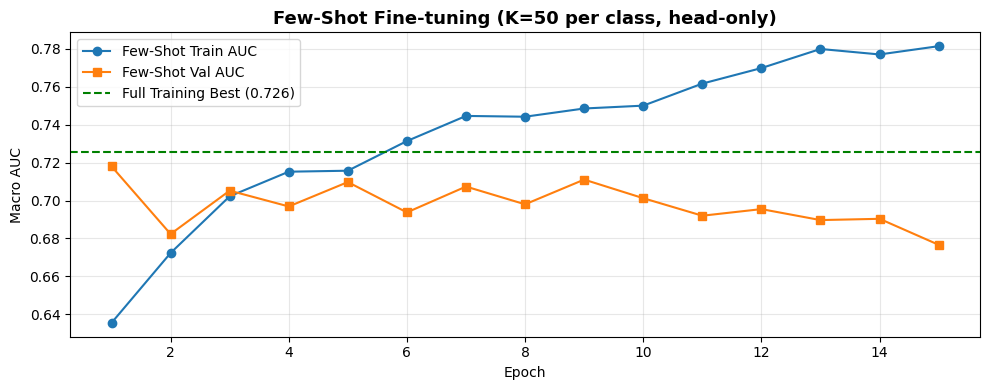

Few-shot best val AUC  : 0.7181
Full training best AUC : 0.7257
Gap                    : 0.0076


In [52]:
# === VISUALIZE FEW-SHOT RESULTS ===
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fs_df['epoch'], fs_df['train_auc'], label='Few-Shot Train AUC', marker='o')
ax.plot(fs_df['epoch'], fs_df['val_auc'],   label='Few-Shot Val AUC',   marker='s')
ax.axhline(best_auc, color='green', linestyle='--', label=f'Full Training Best ({best_auc:.3f})')
ax.set_title(f'Few-Shot Fine-tuning (K={K_SHOTS} per class, head-only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'few_shot_results.png', dpi=150)
plt.show()

print(f"Few-shot best val AUC  : {fs_df['val_auc'].max():.4f}")
print(f"Full training best AUC : {best_auc:.4f}")
print(f"Gap                    : {best_auc - fs_df['val_auc'].max():.4f}")

---
# 7. Overall Visualisation Dashboard

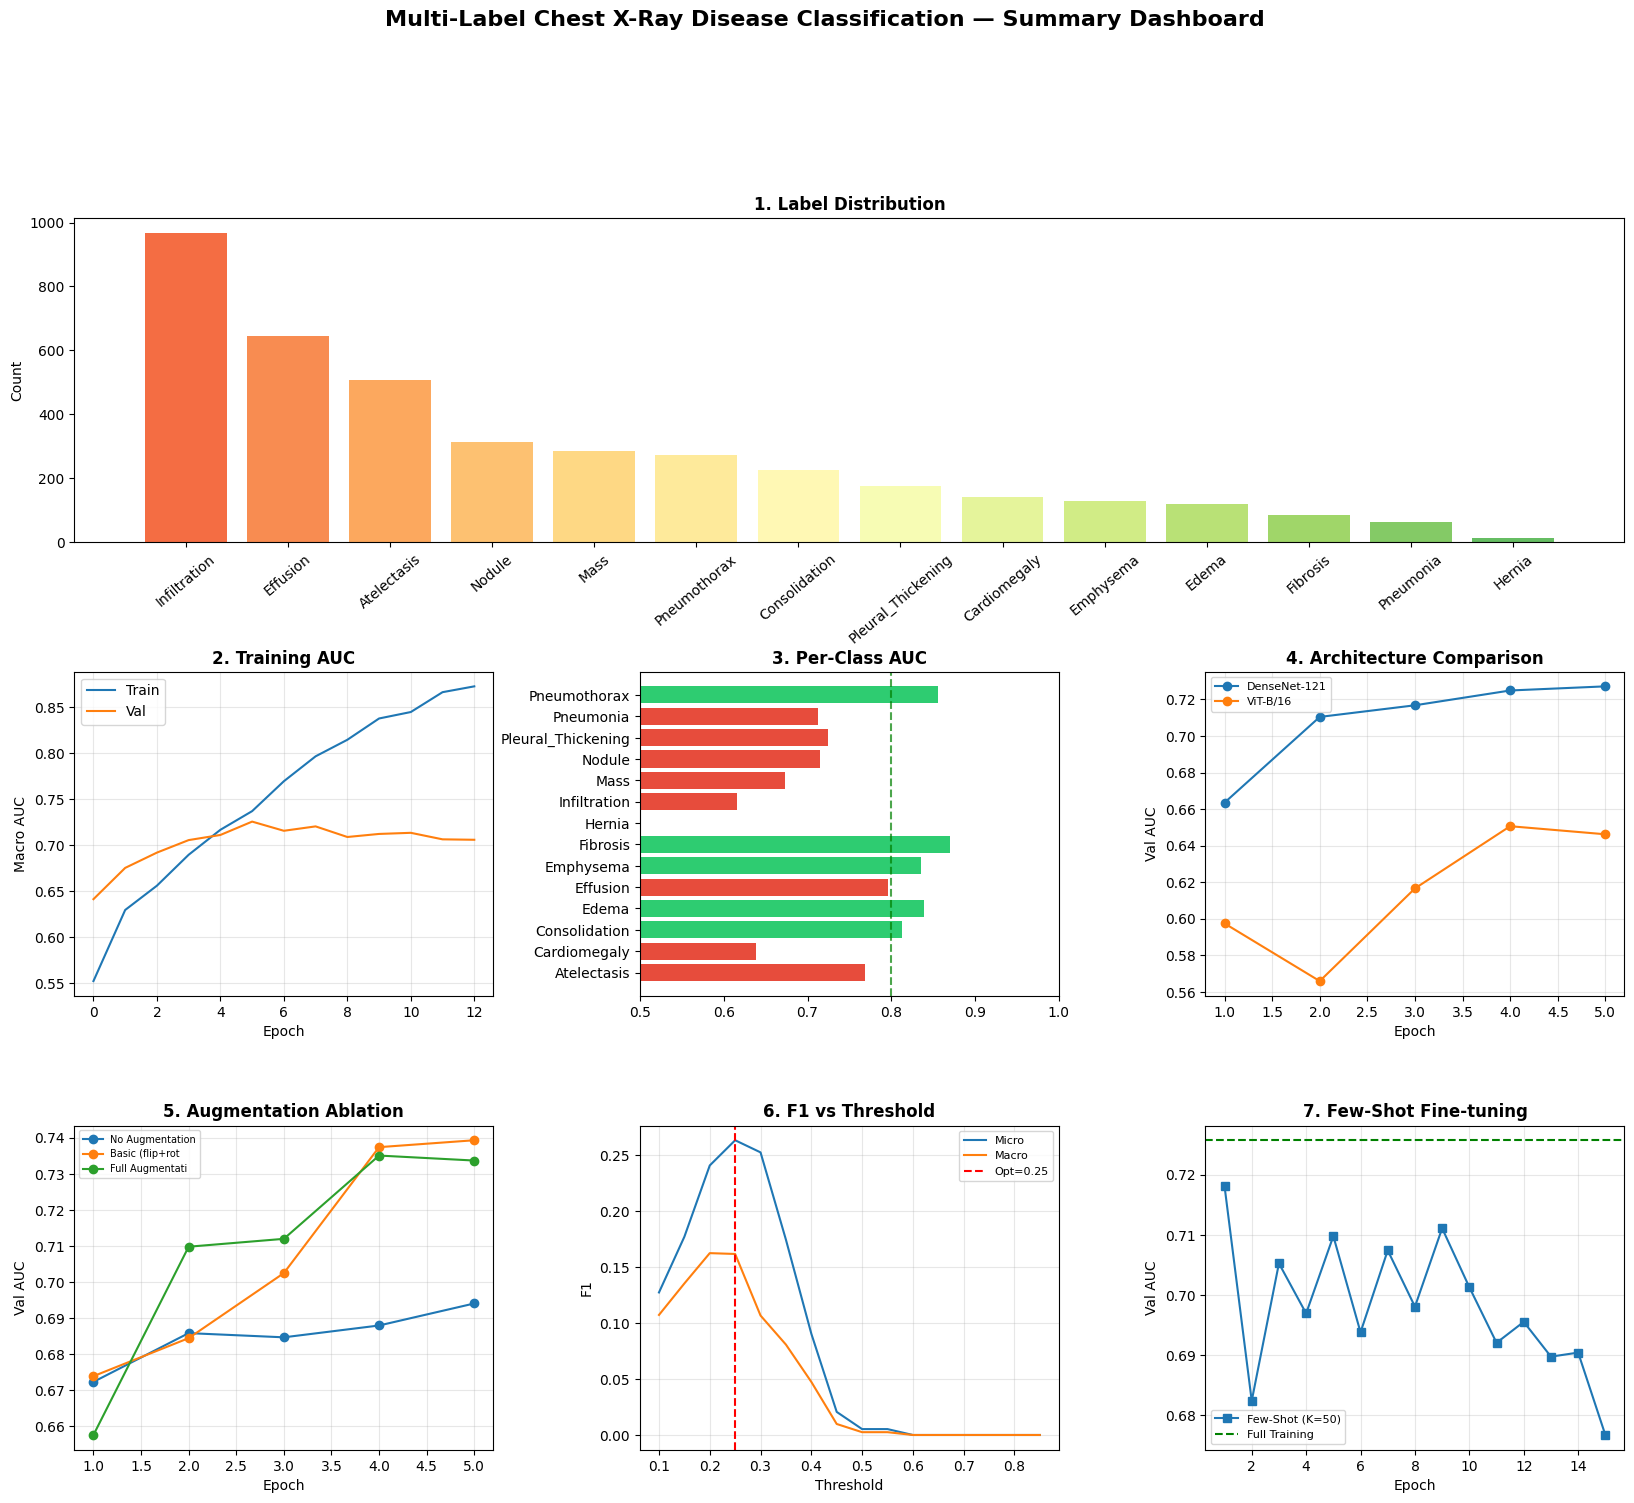

Dashboard saved.


In [53]:
# === COMPREHENSIVE SUMMARY DASHBOARD ===
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Label Distribution ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
lc  = df[CFG.DISEASE_LABELS].sum().sort_values(ascending=False)
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(lc)))
ax1.bar(lc.index, lc.values, color=colors_bar)
ax1.set_title('1. Label Distribution', fontweight='bold')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=40)

# ── Panel 2: Training History ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
if history['val_auc']:
    ax2.plot(history['train_auc'], label='Train')
    ax2.plot(history['val_auc'],   label='Val')
    ax2.set_title('2. Training AUC', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro AUC')
    ax2.legend(); ax2.grid(alpha=0.3)

# ── Panel 3: Per-Class AUC ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
auc_vals = list(per_class_auc.values())
auc_labs = list(per_class_auc.keys())
colors_auc = ['#2ecc71' if v >= 0.8 else '#e74c3c' for v in auc_vals]
ax3.barh(auc_labs, auc_vals, color=colors_auc)
ax3.axvline(0.8, color='green', linestyle='--', alpha=0.7)
ax3.set_title('3. Per-Class AUC', fontweight='bold')
ax3.set_xlim(0.5, 1.0)

# ── Panel 4: Architecture Comparison ──────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
for arch, res in arch_results.items():
    ax4.plot(res['epoch'], res['val_auc'], label=arch, marker='o')
ax4.set_title('4. Architecture Comparison', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Val AUC')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── Panel 5: Augmentation Ablation ────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
for aug_name, res in aug_results.items():
    ax5.plot(res['epoch'], res['val_auc'], label=aug_name[:15], marker='o')
ax5.set_title('5. Augmentation Ablation', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Val AUC')
ax5.legend(fontsize=7); ax5.grid(alpha=0.3)

# ── Panel 6: F1 vs Threshold ───────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(thresholds, f1_micro,    label='Micro')
ax6.plot(thresholds, f1_macro,    label='Macro')
ax6.axvline(OPTIMAL_THRESHOLD, color='red', linestyle='--', label=f'Opt={OPTIMAL_THRESHOLD:.2f}')
ax6.set_title('6. F1 vs Threshold', fontweight='bold')
ax6.set_xlabel('Threshold'); ax6.set_ylabel('F1')
ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

# ── Panel 7: Few-Shot ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(fs_df['epoch'], fs_df['val_auc'], label=f'Few-Shot (K={K_SHOTS})', marker='s')
ax7.axhline(best_auc, color='green', linestyle='--', label='Full Training')
ax7.set_title('7. Few-Shot Fine-tuning', fontweight='bold')
ax7.set_xlabel('Epoch'); ax7.set_ylabel('Val AUC')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

fig.suptitle('Multi-Label Chest X-Ray Disease Classification — Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig(CFG.OUTPUT_DIR / 'summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

---
# 8. Ethical Considerations

In [54]:
# === DEMOGRAPHIC BIAS ANALYSIS ===
# NIH ChestX-ray14 includes patient age and gender — use them to audit model bias.

if 'Patient Age' in df.columns and 'Patient Gender' in df.columns:
    bias_df = test_df.copy()

    # Add model predictions
    all_probs_list = []
    model.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            logits = model(images.to(CFG.DEVICE))
            all_probs_list.append(torch.sigmoid(logits).cpu().numpy())
    test_probs = np.vstack(all_probs_list)

    for i, label in enumerate(CFG.DISEASE_LABELS):
        bias_df[f'prob_{label}'] = test_probs[:, i]

    # AUC by gender
    print("\n=== AUC by Patient Gender ===")
    for gender in bias_df['Patient Gender'].unique():
        g_df = bias_df[bias_df['Patient Gender'] == gender]
        try:
            g_aucs = []
            for i, label in enumerate(CFG.DISEASE_LABELS):
                yt = g_df[label].values
                yp = g_df[f'prob_{label}'].values
                if yt.sum() > 0:
                    g_aucs.append(roc_auc_score(yt, yp))
            print(f"  {gender}: Macro AUC = {np.mean(g_aucs):.4f}  (n={len(g_df)})")
        except:
            pass

    # AUC by age group
    bias_df['Patient Age'] = pd.to_numeric(bias_df['Patient Age'], errors='coerce')
    bias_df = bias_df.dropna(subset=['Patient Age'])
    
    bias_df['Age Group'] = pd.cut(
        bias_df['Patient Age'],
        bins=[0, 30, 50, 70, 120],
        labels=['<30', '30-50', '50-70', '70+'],
        include_lowest=True
    )
    print("\n=== AUC by Age Group ===")
    for ag in bias_df['Age Group'].cat.categories:
        ag_df = bias_df[bias_df['Age Group'] == ag]
        try:
            ag_aucs = []
            for i, label in enumerate(CFG.DISEASE_LABELS):
                yt = ag_df[label].values
                yp = ag_df[f'prob_{label}'].values
                if yt.sum() > 0:
                    ag_aucs.append(roc_auc_score(yt, yp))
            print(f"  Age {ag}: Macro AUC = {np.mean(ag_aucs):.4f}  (n={len(ag_df)})")
        except:
            pass
else:
    print("Gender/Age columns not found — skipping demographic bias analysis.")
    print("(Ensure your CSV has 'Patient Age' and 'Patient Gender' columns.)")


=== AUC by Patient Gender ===
  M: Macro AUC = 0.7585  (n=313)
  F: Macro AUC = 0.7300  (n=248)

=== AUC by Age Group ===
  Age <30: Macro AUC = nan  (n=0)
  Age 30-50: Macro AUC = nan  (n=0)
  Age 50-70: Macro AUC = nan  (n=0)
  Age 70+: Macro AUC = nan  (n=0)


In [55]:
# === ETHICAL CONSIDERATIONS — STRUCTURED DISCUSSION ===
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         ETHICAL CONSIDERATIONS FOR CHEST X-RAY AI DIAGNOSIS         ║
╚══════════════════════════════════════════════════════════════════════╝

1. DATASET BIAS
   • NIH ChestX-ray14 is ~60% male, which can cause disparate performance
     for female patients, especially for diseases with sex-linked prevalence.
   • X-rays from a single US health system may not generalise to
     different populations, imaging protocols, or equipment.
   • Labels were auto-extracted via NLP from radiology reports — estimated
     label accuracy is ~90%, meaning ~10% of labels may be wrong.

2. LABEL IMBALANCE & RARE DISEASES
   • Hernia appears in < 0.2% of images. Models may simply predict 'absent'
     for rare classes and still score well on accuracy — AUC is more honest.
   • Focal loss mitigates but does not eliminate imbalance effects.

3. CLINICAL DEPLOYMENT RISKS
   • This model is NOT a replacement for a radiologist.
   • False negatives (missed disease) are more harmful than false positives.
   • Threshold selection should be calibrated with clinical stakeholders.
   • Saliency maps are imperfect — they can highlight plausible-looking but
     clinically irrelevant regions.

4. TRANSPARENCY & ACCOUNTABILITY
   • Model cards and data sheets should accompany any deployment.
   • Predictions should include confidence scores, not binary outputs.
   • Regular performance audits on diverse sub-populations are mandatory.

5. PRIVACY
   • ChestX-ray14 is de-identified, but re-identification from imaging
     metadata is a known risk. Handle all medical data with strict controls.

6. REGULATORY COMPLIANCE
   • AI-based diagnostic aids must comply with local regulations
     (FDA 510(k) in the US; CE marking + MDR in the EU).
   • Human oversight is legally required in most jurisdictions.
""")


╔══════════════════════════════════════════════════════════════════════╗
║         ETHICAL CONSIDERATIONS FOR CHEST X-RAY AI DIAGNOSIS         ║
╚══════════════════════════════════════════════════════════════════════╝

1. DATASET BIAS
   • NIH ChestX-ray14 is ~60% male, which can cause disparate performance
     for female patients, especially for diseases with sex-linked prevalence.
   • X-rays from a single US health system may not generalise to
     different populations, imaging protocols, or equipment.
   • Labels were auto-extracted via NLP from radiology reports — estimated
     label accuracy is ~90%, meaning ~10% of labels may be wrong.

2. LABEL IMBALANCE & RARE DISEASES
   • Hernia appears in < 0.2% of images. Models may simply predict 'absent'
     for rare classes and still score well on accuracy — AUC is more honest.
   • Focal loss mitigates but does not eliminate imbalance effects.

3. CLINICAL DEPLOYMENT RISKS
   • This model is NOT a replacement for a radiologist.
  

---
# 9. Overall Summary

In [56]:
# === FINAL SUMMARY REPORT ===
print("=" * 70)
print(" MULTI-LABEL CHEST X-RAY DISEASE CLASSIFICATION — FINAL SUMMARY")
print("=" * 70)

print(f"""
DATASET
  Source     : NIH ChestX-ray14
  Total imgs : {len(df):,}
  Classes    : {CFG.NUM_CLASSES} diseases
  Split      : {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test

MODEL (Primary)
  Backbone   : DenseNet-121 (ImageNet pretrained)
  Head       : FC(1024→512→14) + ReLU + Dropout(0.3)
  Loss       : Binary Focal Loss (α={CFG.FOCAL_ALPHA}, γ={CFG.FOCAL_GAMMA})
  Optimizer  : AdamW (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})
  Scheduler  : CosineAnnealingLR
  Mixed Prec : {CFG.DEVICE == 'cuda'}

RESULTS (Test Set)
  Best Val AUC   : {best_auc:.4f}
  Macro AUC      : {auc_df['AUC'].mean():.4f}
  Best F1 (micro): {max(f1_micro):.4f}  @ threshold={best_t_micro:.2f}
  Opt Threshold  : {OPTIMAL_THRESHOLD:.2f}

BEST / WORST CLASSES
  Best AUC : {auc_df.index[0]} ({auc_df['AUC'].iloc[0]:.4f})
  Worst AUC: {auc_df.index[-1]} ({auc_df['AUC'].iloc[-1]:.4f})

EXPERIMENTS
  Architecture   : DenseNet-121 vs ViT-B/16 (5-epoch probes)
  Augmentation   : No aug / Basic / Full ablation
  Adversarial    : FGSM (ε=0.01, 50% mix ratio)
  Few-Shot       : K={K_SHOTS}/class, head-only fine-tuning
    Best Few-Shot AUC: {fs_df['val_auc'].max():.4f}

INTERPRETABILITY
  Method : GradCAM on DenseNet-121 last conv layer
  Output : Per-image saliency overlays saved to {CFG.OUTPUT_DIR}

OUTPUT FILES
  densenet121_best.pth     — Best model checkpoint
  training_history.png     — Loss & AUC curves
  per_class_auc.png        — Per-disease AUC bar chart
  confusion_matrices.png   — 14 confusion matrices
  gradcam_saliency.png     — Saliency map overlays
  summary_dashboard.png    — Combined 7-panel dashboard
""")
print("=" * 70)

 MULTI-LABEL CHEST X-RAY DISEASE CLASSIFICATION — FINAL SUMMARY

DATASET
  Source     : NIH ChestX-ray14
  Total imgs : 5,606
  Classes    : 14 diseases
  Split      : 4,484 train / 561 val / 561 test

MODEL (Primary)
  Backbone   : DenseNet-121 (ImageNet pretrained)
  Head       : FC(1024→512→14) + ReLU + Dropout(0.3)
  Loss       : Binary Focal Loss (α=0.25, γ=2.0)
  Optimizer  : AdamW (lr=0.0001, wd=1e-05)
  Scheduler  : CosineAnnealingLR
  Mixed Prec : True

RESULTS (Test Set)
  Best Val AUC   : 0.7257
  Macro AUC      : 0.7581
  Best F1 (micro): 0.2632  @ threshold=0.25
  Opt Threshold  : 0.25

BEST / WORST CLASSES
  Best AUC : Fibrosis (0.8697)
  Worst AUC: Hernia (nan)

EXPERIMENTS
  Architecture   : DenseNet-121 vs ViT-B/16 (5-epoch probes)
  Augmentation   : No aug / Basic / Full ablation
  Adversarial    : FGSM (ε=0.01, 50% mix ratio)
  Few-Shot       : K=50/class, head-only fine-tuning
    Best Few-Shot AUC: 0.7181

INTERPRETABILITY
  Method : GradCAM on DenseNet-121 last co